
# **Analysis using Clustering with the K-MEANS model**


## **Helper Functions and variables**

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import gaussian_kde
from google.colab import files
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-white')

### Define Colors, iconicity and categories

In [2]:
import pandas as pd
!pip install distinctipy
!pip install adjustText

In [3]:
# ==============================================================================
# DEFINE COLORS AND ICONICITY CATEGORIES
# ==============================================================================

# Categories of iconicity (8 levels)
CATEGORY_COLORS = {
    1: '#8b0000',  # Rojo oscuro
    2: '#e74c3c',  # Rojo
    3: '#ff6b35',  # Naranja rojizo
    4: '#f39c12',  # Naranja
    5: '#f1c40f',  # Amarillo
    6: '#3498db',  # Azul claro
    7: '#2874a6',  # Azul oscuro
    8: '#9b59b6'   # Morado
}

CATEGORY_LABELS = {
    1: '1.0-1.5', 2: '1.5-2.0', 3: '2.0-2.5', 4: '2.5-3.0',
    5: '3.0-3.5', 6: '3.5-4.0', 7: '4.0-4.5', 8: '4.5-5.0'
}

# Colors for K-Means clusters

# CLUSTER_COLORS = [
#     "#FF0000",  # Rojo
#     "#0000FF",  # Azul
#     "#00FF00",  # Verde
#     "#FFFF00",  # Amarillo
#     "#FF00FF",  # Magenta
#     "#00FFFF",  # Cian
#     "#D9D9D9",  # Negro
#     "#FFA500",  # Naranja
#     "#8B4513",  # Marrón
#     "#800080"   # Morado
# ]

# CLUSTER_COLORS = [
#     "#1F77B4",  # azul
#     "#FF7F0E",  # naranja
#     "#2CA02C",  # verde
#     "#D62728",  # rojo
#     "#9467BD",  # morado
#     "#8C564B",  # marrón
#     "#E377C2",  # rosa
#     "#7F7F7F",  # gris
#     "#BCBD22",  # oliva
#     "#17BECF"   # cian
# ]

CLUSTER_COLORS = [
    "#1F77B4",  # azul
    "#AEC7E8",  # azul claro
    "#FF7F0E",  # naranja
    "#FFBB78",  # naranja claro
    "#2CA02C",  # verde
    "#98DF8A",  # verde claro
    "#D62728",  # rojo
    "#FF9896",  # rojo claro
    "#9467BD",  # morado
    "#C5B0D5",  # morado claro
    "#8C564B",  # marrón
    "#C49C94",  # marrón claro
    "#E377C2",  # rosa
    "#FF1493",  # rosa fuerte
    "#7F7F7F",  # gris
    "#C7C7C7",  # gris claro
    "#BCBD22",  # oliva
    "#DBDB8D",  # oliva claro
    "#17BECF",  # cian
    "#9EDAE5"   # cian claro
]


def categorize_iconicity_8(icon):
    """Categorizing iconicity into 8 levels"""
    if icon <= 1.5: return 1
    elif icon <= 2.0: return 2
    elif icon <= 2.5: return 3
    elif icon <= 3.0: return 4
    elif icon <= 3.5: return 5
    elif icon <= 4.0: return 6
    elif icon <= 4.5: return 7
    else: return 8

### Helpers for Options to Reduce Dimensionality TSNE, PCA and KMeans

In [4]:
# ==============================================================================
# REDUCCIÓN DIMENSIONAL CON PCA
# ==============================================================================

from numpy.ma.core import var
from sklearn.decomposition import PCA

print("\n" + "="*80)
print("REDUCCIÓN DIMENSIONAL CON (PCA)")
print("="*80)

def apply_pca(data, embedding_cols, lang_name):
    """Aplicar PCA a embeddings"""

    print(f"\n📊 {lang_name}:")

    X = data[embedding_cols].values

    # PCA a 50 componentes (para K-Means)
    print("   🔹 PCA a 50 componentes (para clustering)...")
    pca_50 = PCA(n_components=50, random_state=42)
    X_pca_50 = pca_50.fit_transform(X)
    var_50 = pca_50.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada (50 PC): {var_50:.1%}")

    # PCA a 3 componentes (para visualización 3D)
    print("   🔹 PCA a 3 componentes (para visualización 3D)...")
    pca_3 = PCA(n_components=3, random_state=42)
    X_pca_3 = pca_3.fit_transform(X)
    var_3 = pca_3.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada (3 PC): {var_3:.1%}")
    print(f"      PC1: {pca_3.explained_variance_ratio_[0]:.1%}")
    print(f"      PC2: {pca_3.explained_variance_ratio_[1]:.1%}")
    print(f"      PC3: {pca_3.explained_variance_ratio_[2]:.1%}")


    # PCA a 2 componentes (para visualización 2D si se necesita)
    print("   🔹 PCA a 2 componentes ")
    pca_2 = PCA(n_components=2, random_state=42)
    X_pca_2 = pca_2.fit_transform(X)
    var_2 = pca_2.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada (2 PC): {var_2:.1%}")
    print(f"      PC1: {pca_2.explained_variance_ratio_[0]:.1%}")
    print(f"      PC2: {pca_2.explained_variance_ratio_[1]:.1%}")

    # return X_pca_50, X_pca_3, X_pca_2, pca_3
    return X_pca_50, pca_50



REDUCCIÓN DIMENSIONAL CON (PCA)


In [5]:

def apply_tsne(X, lang_name):
    """Aplicar T-SNE sobre embeddings PCA"""

    perplexity = min(30, len(X) // 4)
    # perplexity = min(25, len(X) // 3)
    tsne = TSNE(n_components=2, metric='cosine', perplexity=perplexity,
                random_state=42, n_iter=1000, verbose=0)
    coords_tsne = tsne.fit_transform(X)

    print(f"   ✅ T-SNE completado")

    return coords_tsne

In [6]:
def apply_kmeans(X, data, k_optimal, lang_name):
    """Aplicar K-Means con k óptimo"""

    print(f"\n{lang_name} con k={k_optimal}:")

    kmeans = KMeans(n_clusters=k_optimal, n_init=50, max_iter=500, random_state=42)
    clusters = kmeans.fit_predict(X)

    # Métricas de calidad
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)

    print(f"   Clustering completado")
    print(f"   Silhouette Score: {silhouette:.3f} (más cerca de 1 = mejor)")
    print(f"   Davies-Bouldin Index: {davies_bouldin:.3f} (más cerca de 0 = mejor)")

    # Asignar clusters
    data['cluster'] = clusters

    # Estadísticas por cluster
    print(f"\n   Distribución de señas por cluster:")
    for c in range(k_optimal):
        count = (clusters == c).sum()
        pct = (count / len(clusters)) * 100
        mean_icon = data[data['cluster'] == c]['iconicity'].mean()
        print(f"      Cluster {c}: {count} señas ({pct:.1f}%) - Iconicidad media: {mean_icon:.2f}")

    return data

In [7]:
def analyze_clusters(data, lang_name, k_optimal):
    """Análisis detallado de clusters"""

    print(f"\n{'='*60}")
    print(f"{lang_name} - ANÁLISIS DE CLUSTERS (k={k_optimal})")
    print(f"{'='*60}")

    stats_text = []
    stats_text.append(f"\n{lang_name} - ANÁLISIS DE CLUSTERS (k={k_optimal})\n")
    stats_text.append("="*60 + "\n")

    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]

        print(f"\n CLUSTER {c}:")
        stats_text.append(f"\nCLUSTER {c}:\n")
        stats_text.append("-"*40 + "\n")

        # Tamaño
        size = len(cluster_data)
        pct = (size / len(data)) * 100
        print(f"   • Tamaño: {size} señas ({pct:.1f}%)")
        stats_text.append(f"Tamaño: {size} señas ({pct:.1f}%)\n")

        # Iconicidad
        icon_mean = cluster_data['iconicity'].mean()
        icon_std = cluster_data['iconicity'].std()
        icon_min = cluster_data['iconicity'].min()
        icon_max = cluster_data['iconicity'].max()
        print(f"   • Iconicidad: {icon_mean:.2f} ± {icon_std:.2f} (rango: {icon_min:.2f} - {icon_max:.2f})")
        stats_text.append(f"Iconicidad: {icon_mean:.2f} ± {icon_std:.2f} (rango: {icon_min:.2f} - {icon_max:.2f})\n")

        # Top 5 señas
        top_5 = cluster_data.nlargest(5, 'iconicity')
        print(f"   • Top 5 más icónicas:")
        stats_text.append("Top 5 más icónicas:\n")
        for _, row in top_5.iterrows():
            print(f"      {row['word']:15s} → {row['iconicity']:.2f}")
            stats_text.append(f"  {row['word']:15s} → {row['iconicity']:.2f}\n")

        # Todas las palabras del cluster
        words = sorted(cluster_data['word'].tolist())
        print(f"   • Todas las señas ({len(words)}):")
        print(f"      {', '.join(words[:20])}" + ("..." if len(words) > 20 else ""))
        stats_text.append(f"Todas las señas: {', '.join(words)}\n")

    return ''.join(stats_text)

In [8]:
def apply_tsne_3d(X, lang_name):
    """Aplicar T-SNE sobre embeddings PCA"""

    perplexity = min(30, len(X) // 4)
    tsne = TSNE(n_components=3, metric='cosine', perplexity=perplexity,
                random_state=42, n_iter=1000, verbose=0)
    coords_tsne = tsne.fit_transform(X)

    print(f"   ✅ T-SNE completado")

    return coords_tsne

In [9]:
def reduce_to_2d_PCA_TSNE(data, embedding_cols, lang_name):
    """Reducir embeddings a 2D usando PCA + T-SNE"""

    print(f"\n📊 {lang_name}:")

    X = data[embedding_cols].values

    # PCA primero
    print("   🔹 PCA a 50 componentes...")
    n_components_pca = min(50, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_components_pca, random_state=42)
    X_pca = pca.fit_transform(X)
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"   ✅ Varianza explicada: {var_explained:.1%}")

    # T-SNE a 2D
    print("   🔹 T-SNE a 3D...")
    perplexity = min(30, X.shape[0] // 4)
    tsne = TSNE(
        n_components=2,
        metric='cosine',
        perplexity=perplexity,
        random_state=42,
        n_iter=1000,
        verbose=0
    )
    coords_2d = tsne.fit_transform(X_pca)

    print(f"   ✅ Reducción completada")

    return coords_2d, tsne

### Elbow Method

In [10]:
# ==============================================================================
# MÉTODO DEL CODO (ELBOW METHOD)
#==============================================================================

def elbow_method(X, lang_name, k_range=range(2, 11)):
    """Aplicar método del codo para encontrar k óptimo"""

    print(f"\n🔹 {lang_name}:")

    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []
    listModels = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init=50, max_iter=500, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

        # Silhouette score
        # score = silhouette_score(X, kmeans.labels_)
        # silhouette_scores.append(score)

        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
        davies_bouldin_scores.append(davies_bouldin_score(X, kmeans.labels_))
        calinski_harabasz_scores.append(calinski_harabasz_score(X, kmeans.labels_))

        listModels.append(kmeans)

        #print(f"   k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={score:.3f}")

    # Calcular "codo" (máxima curvatura)
    # Método: segunda derivada
    inertias_arr = np.array(inertias)
    if len(inertias_arr) > 2:
        # Calcular segunda derivada
        first_deriv = np.diff(inertias_arr)
        second_deriv = np.diff(first_deriv)
        elbow_idx = np.argmax(np.abs(second_deriv)) + 2  # +2 porque perdemos 2 puntos
        k_optimal = list(k_range)[elbow_idx]
    else:
        k_optimal = 3  # Default

    k_list = list(k_range)
    print(f"\n   💡 k óptimo sugerido (método del codo): {k_optimal}")
    print(f"   💡 k con mejor Silhouette:        {k_list[np.argmax(silhouette_scores)]} (↑ mayor es mejor)")
    print(f"   💡 k con mejor Davies-Bouldin:    {k_list[np.argmin(davies_bouldin_scores)]} (↓ menor es mejor)")
    print(f"   💡 k con mejor Calinski-Harabasz: {k_list[np.argmax(calinski_harabasz_scores)]} (↑ mayor es mejor)")

    return inertias, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores, k_optimal

### Plot k-means

In [11]:
def plot_kmeans_clusters(data, lang_name, k_optimal, filename):
    """Graficar clusters K-Means con todas las señas etiquetadas"""

    print(f"\n📊 Generando gráfica para {lang_name}...")

    fig, ax = plt.subplots(figsize=(16, 14))

    # Scatter por cluster
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        ax.scatter(
            cluster_data['tsne_x'], cluster_data['tsne_y'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            s=350,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c} (n={len(cluster_data)})',
            zorder=3
        )

    # Etiquetar TODAS las señas
    print(f"   🔹 Etiquetando {len(data)} señas...")
    for _, row in data.iterrows():
        annotation_text = ax.annotate(
            row['word'].lower(),
            (row['tsne_x'], row['tsne_y']), # tsne_x, tsne_y
            fontsize=12,
            fontweight='bold',
            xytext=(5, 5),
            textcoords='offset points',
            alpha=0.8,
            zorder=4
        )
        annotation_text.set_url("https://diccionariolsp.pucp.edu.pe/search-by-text")

    ax.set_title(f'{lang_name}: K-Means Clustering (k={k_optimal})',
                 fontsize=16, fontweight='bold', pad=20)
    # dim_reduc_method brings the proper information for axis names
    ax.set_xlabel('TSNE Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('TSNE Dimension 2', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"   ✅ {filename} guardada")

In [12]:
from adjustText import adjust_text

def plot_kmeans_clusters_new(data, lang_name, k_optimal, filename):
    """Graficar clusters K-Means con todas las señas etiquetadas (estable)."""

    print(f"\n📊 Generando gráfica para {lang_name}...")

    fig, ax = plt.subplots(figsize=(22, 18))

    # 1) Scatter por cluster
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        ax.scatter(
            cluster_data['tsne_x'], cluster_data['tsne_y'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            s=350,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c} (n={len(cluster_data)})',
            zorder=3
        )

    # Guarda límites y EXPÁNDELOS ligeramente
    ax.autoscale(True)  # Primero autoscale
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Expande límites 5% para incluir outliers
    x_range = xlim[1] - xlim[0]
    y_range = ylim[1] - ylim[0]
    xlim_expanded = (xlim[0] - 0.05*x_range, xlim[1] + 0.05*x_range)
    ylim_expanded = (ylim[0] - 0.05*y_range, ylim[1] + 0.05*y_range)

    # FILTRAR puntos dentro de límites expandidos
    data_visible = data[
        (data['tsne_x'] >= xlim_expanded[0]) &
        (data['tsne_x'] <= xlim_expanded[1]) &
        (data['tsne_y'] >= ylim_expanded[0]) &
        (data['tsne_y'] <= ylim_expanded[1])
    ].copy()

    n_filtered = len(data) - len(data_visible)
    if n_filtered > 0:
        print(f"⚠️ {n_filtered} puntos outliers excluidos del etiquetado")

    ax.autoscale(False)  # Ahora sí congela límites
    ax.set_xlim(xlim_expanded)
    ax.set_ylim(ylim_expanded)

    # 2) Crear etiquetas SOLO para puntos visibles
    texts = []
    for _, row in data_visible.iterrows():
        txt = ax.text(
            float(row["tsne_x"]),
            float(row["tsne_y"]),
            str(row["word"]).lower(),
            fontsize=10,
            alpha=0.9,
            zorder=4,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="lightgray",
                     alpha=0.9, linewidth=0.5)
        )
        texts.append(txt)

    # AJUSTE OPTIMIZADO
    adjust_text(
        texts,
        ax=ax,

        # Mantiene textos cerca de puntos
        force_pull=(1.2, 1.2),
        force_explode=(0.6, 0.6),

        # Movimiento moderado
        only_move={'text': 'xy'},
        max_move=(12, 12),

        # Separación
        expand_text=(1.06, 1.06),
        force_text=(0.08, 0.08),
        force_points=(0.04, 0.04),

        # Flechas para textos alejados
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            lw=0.5,
            alpha=0.4
        ),

        # Iteraciones
        lim=150,

        # NO expandir el gráfico
        expand_points=(1.0, 1.0),
        expand_objects=(1.0, 1.0)
    )

    # 3) Estética
    ax.set_title(f"{lang_name}: K-Means Clustering (k={k_optimal})",
                 fontsize=18, fontweight="bold", pad=20)
    ax.set_xlabel("TSNE Dimension 1", fontsize=14, fontweight="bold")
    ax.set_ylabel("TSNE Dimension 2", fontsize=14, fontweight="bold")

    ax.legend(loc="best", fontsize=10, framealpha=0.95,
              title=f"{len(data_visible)}/{len(data)} signs shown")
    ax.grid(True, alpha=0.15)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"✅ {filename} guardada ({len(data_visible)} etiquetas)")

In [13]:

def plot_clusters_iconicity_size(data, lang_name, k_optimal, filename):
    """Clusters con color, iconicidad con tamaño"""

    print(f"\n📊 Generando gráfica para {lang_name}...")

    fig, ax = plt.subplots(figsize=(18, 14))

    # Normalizar iconicidad para tamaño de puntos (50-500)
    icon_normalized = (data['iconicity'] - data['iconicity'].min()) / \
                      (data['iconicity'].max() - data['iconicity'].min())
    sizes = 80 + icon_normalized * 400  # Tamaño de 80 a 480

    # Scatter por cluster con tamaño por iconicidad
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        cluster_sizes = sizes[data['cluster'] == c]

        ax.scatter(
            cluster_data['tsne_x'], cluster_data['tsne_y'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            # c=CLUSTER_COLORS[c],
            s=cluster_sizes,
            alpha=0.6,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c}',
            zorder=3
        )

    # Etiquetar TODAS las señas con iconicidad
    print(f"   🔹 Etiquetando {len(data)} señas...")
    for _, row in data.iterrows():
        label = f"{row['word'].lower()} ({row['iconicity']:.2f})"
        ax.annotate(
            label,
            (row['tsne_x'], row['tsne_y']),
            fontsize=8,
            fontweight='bold',
            xytext=(3, 3),
            textcoords='offset points',
            alpha=0.75,
            zorder=4
        )

    ax.set_title(f'{lang_name}: K-Means Clusters + Iconicity\n' +
                 f'Color = Cluster, Size = Iconicity',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('TSNE Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('TSNE Dimension 2', fontsize=13, fontweight='bold')

    # Leyenda de clusters
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9, title='Clusters',
             title_fontsize=11)

    # Agregar texto explicativo de tamaños
    textstr = 'Size = Iconicity\nSmaller = Lower\nLarger = Higher'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

    ax.grid(True, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f" {filename} guardada")

In [14]:
def plot_facet_grid_clusters(data, lang_name, k_optimal, filename):
    """Facet grid: subplot por cluster, color por iconicidad"""

    print(f"\n Generando facet grid para {lang_name}...")

    # Calcular grid óptimo
    n_cols = min(3, k_optimal)
    n_rows = (k_optimal + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = axes.flatten() if k_optimal > 1 else [axes]

    for c in range(k_optimal):
        ax = axes[c]
        cluster_data = data[data['cluster'] == c]

        # Scatter por categoría de iconicidad
        for cat in range(1, 9):
            cat_data = cluster_data[cluster_data['icon_category'] == cat]
            if len(cat_data) > 0:
                ax.scatter(
                    cat_data['tsne_x'], cat_data['tsne_y'], # tsne_x, tsne_y
                    c=CATEGORY_COLORS[cat],
                    s=100,
                    alpha=0.7,
                    edgecolors='black',
                    linewidths=1.2,
                    label=CATEGORY_LABELS[cat],
                    zorder=3
                )

        # Etiquetar señas del cluster
        print(f" Cluster {c}: Etiquetando {len(cluster_data)} señas...")
        for _, row in cluster_data.iterrows():
            ax.annotate(
                row['word'].lower(),
                (row['tsne_x'], row['tsne_y']),
                fontsize=8,
                fontweight='bold',
                xytext=(2, 2),
                textcoords='offset points',
                alpha=0.8,
                zorder=4
            )

        ax.set_title(f'Cluster {c} (n={len(cluster_data)})',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('tsne_x', fontsize=10)
        ax.set_ylabel('tsne_y', fontsize=10)
        ax.legend(fontsize=7, loc='best', framealpha=0.9, ncol=2)
        ax.grid(True, alpha=0.2)
        ax.set_xticks([])
        ax.set_yticks([])

    # Ocultar subplots vacíos
    for idx in range(k_optimal, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f'{lang_name}: Facet Grid by Cluster\n' +
                 f'Color = Iconicity Category',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"{filename} guardada")

In [15]:
from mpl_toolkits.mplot3d import Axes3D

def plot_kmeans_clusters_3d(data, lang_name, k_optimal, filename,
                             x_col='x', y_col='y', z_col='z',
                             xlabel='PC1', ylabel='PC2', zlabel='PC3'):
    """Graficar clusters K-Means en 3D. Soporta PCA (x,y,z) o T-SNE 3D (tsne_x/y/z)."""

    print(f"\n📊 Generando gráfica 3D para {lang_name}...")

    fig = plt.figure(figsize=(18, 14))
    ax = fig.add_subplot(111, projection='3d')

    # 1) Scatter 3D por cluster
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        ax.scatter(
            cluster_data[x_col], cluster_data[y_col], cluster_data[z_col],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            s=120, alpha=0.8, edgecolors='black', linewidths=0.8,
            label=f'Cluster {c} (n={len(cluster_data)})', zorder=3
        )

    # 2) Etiquetas de texto por seña

    for _, row in data.iterrows():
        ax.text(float(row[x_col]), float(row[y_col]), float(row[z_col]),
                str(row['word']).lower(),
                fontsize=6, alpha=0.75, ha='center', va='bottom', color='#333333')

    ax.set_title(f"{lang_name}: K-Means 3D — {xlabel}/{ylabel}/{zlabel} (k={k_optimal})",
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold', labelpad=10)
    ax.set_zlabel(zlabel, fontsize=12, fontweight='bold', labelpad=10)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.95,
              title=f'{len(data)} señas | k={k_optimal}')
    ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ {filename} guardada ({len(data)} señas en 3D)")

In [16]:
def plot_pca_3d_iconicity(data, pca_obj, lang_name, filename):
    """PCA 3D con color por categoría de iconicidad"""

    print(f"\n📊 Generando gráfica 3D para {lang_name}...")

    fig = plt.figure(figsize=(18, 14))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter por categoría de iconicidad
    for cat in range(1, 9):
        cat_data = data[data['icon_category'] == cat]
        if len(cat_data) > 0:
            ax.scatter(
                cat_data['x'], cat_data['y'], cat_data['z'],
                c=CATEGORY_COLORS[cat],
                s=120,
                alpha=0.7,
                edgecolors='black',
                linewidths=1.2,
                label=f'{CATEGORY_LABELS[cat]}',
                depthshade=True
            )

    # Etiquetar TODAS las señas
    print(f"Etiquetando {len(data)} señas en 3D...")
    for _, row in data.iterrows():
        label = f"{row['word'].lower()} ({row['iconicity']:.2f})"
        ax.text(
            row['x'], row['y'], row['z'],
            label,
            fontsize=7,
            fontweight='bold',
            alpha=0.7
        )

    # Varianza explicada
    var1 = pca_obj.explained_variance_ratio_[0] * 100
    var2 = pca_obj.explained_variance_ratio_[1] * 100
    var3 = pca_obj.explained_variance_ratio_[2] * 100

    ax.set_xlabel(f'PC1 ({var1:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PC2 ({var2:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_zlabel(f'PC3 ({var3:.1f}% var)', fontsize=12, fontweight='bold')

    ax.set_title(f'{lang_name}: Iconicity in PCA 3D Space\n' +
                 f'Total Variance Explained: {var1+var2+var3:.1f}%',
                 fontsize=16, fontweight='bold', pad=20)

    ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2,
             title='Iconicity Category')

    # Ajustar ángulo de visualización
    ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"{filename} guardada")

In [17]:
def plot_pca_tsne_3d_iconicity(data, pca_obj, k_optimal, lang_name, filename):
    """PCA-TSNE 3D con color por categoría de iconicidad"""

    fig = plt.figure(figsize=(18, 14))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter por categoría de iconicidad


    # Scatter por cluster
    for c in range(k_optimal):
        cluster_data = data[data['cluster'] == c]
        ax.scatter(
            cluster_data['tsne_x_3d'], cluster_data['tsne_y_3d'], cluster_data['tsne_z_3d'],
            c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            # c=CLUSTER_COLORS[c],
            s=120,
            alpha=0.7,
            edgecolors='black',
            linewidths=1.5,
            label=f'Cluster {c} (n={len(cluster_data)})',
            zorder=3
        )

    # Etiquetar TODAS las señas
    # for _, row in data.iterrows():
    #     annotation_text = ax.annotate(
    #         (row['tsne_x_3d'], row['tsne_y_3d']),row['tsne_z_3d'], # tsne_x, tsne_y
    #         fontsize=8,
    #         fontweight='bold',
    #         xytext=(3, 3),
    #         textcoords='offset points',
    #         alpha=0.8,
    #         zorder=4
    #         )

    scale = data[['tsne_x_3d','tsne_y_3d','tsne_z_3d']].to_numpy()
    offset = 0.02 * (scale.max() - scale.min())

    for _, row in data.iterrows():
        ax.text(
            row['tsne_x_3d'] + offset,
            row['tsne_y_3d'] + offset,
            row['tsne_z_3d'] + offset,
            str(row['word']),
            fontsize=8,
            fontweight='bold',
            alpha=0.8,
            zorder=4
        )
    # Varianza explicada
    var1 = pca_obj.explained_variance_ratio_[0] * 100
    var2 = pca_obj.explained_variance_ratio_[1] * 100
    var3 = pca_obj.explained_variance_ratio_[2] * 100

    ax.set_xlabel(f'PCA-TSNE1 ({var1:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'PCA-TSNE2 ({var2:.1f}% var)', fontsize=12, fontweight='bold')
    ax.set_zlabel(f'PCA-TSNE3 ({var3:.1f}% var)', fontsize=12, fontweight='bold')

    ax.set_title(f'{lang_name}: Iconicity in PCA-TSNE 3D Space\n' +
                 f'Total Variance Explained: {var1+var2+var3:.1f}%',
                 fontsize=16, fontweight='bold', pad=20)

    ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2, title="")

    # Ajustar ángulo de visualización
    ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"{filename} guardada")

## **Read input files**

*   The input datasets are the model embeddings (MHI, signERT, "MHI + signERT") associated with iconicity (which were obtained from the notebook **Script_merge_iconicity_embeddings**)

*   The version number is with respesct to the model version.

*   After conducting several tests with different versions and models, the MHI model with version V3 gave us the best results. The following table shows the summary:



      | N° | Language | Method | Version | Dimensiones | Descripción de modelos usados | Descripción de salida de inferencia |
      |----|----------|--------|---------|-------------|--------------------------------|------------------------------------|
      | 1  | LSP      | MHI    | v3      | 4064        | MHI y Triplet entrenado usando LSP Iconicity105 | Mediana representativa por glosa de Iconicity105 |
      | 2  | ASL      | MHI    | v3      | 4064        | MHI y Triplet entrenado usando LSP Iconicity105 | Muestra de los videos de Lewis y Larry |


*   The models that were tested have the following dimensions:
    *   MHI-Only : 4064 dimensions.
    *   signERT: 192 dimensions.
    *   "MHI + signERT": combined 4256 dimensions


### **Type of Phonological Embedding: Examples of the datasets that were tested:**

*   MHI-Only: gets the emedding from the Movement Historic Image
    1.   ASL: emb_phono_ASL_MHIv3.csv
    2.   LSP: emb_phono_LSP_MHIv3.csv

*   signERT: gets the embedding from the very previous to the last layer form the model signERT
    1.   ASL: emb_phono_ASL_signERTv1.csv
    2.   LSP: emb_phono_LSP_signERTv1.csv

*   MHI-signERT:  gets the embedding by combining MHI and the keypoints
    1.   ASL: emb_phono_ASL_MHIv3signERTv1.csv
    2.   LSP: emb_phono_ASL_MHIv3signERTv1.csv

### **Type of Semantic Embedding**

*   ASL: emb_semantic_RAW_ASL_FASTTEXT.csv
*   LSP: emb_semantic_RAW_LSP_FASTTEXT.csv


### **Type of Reduction**

*   PCA
*   TSNE
*   PCA_TSNE



### **1. Experimental Setup for Clustering Analysis**

In [18]:
# ==============================================================================
# DATA LOADING
# ==============================================================================
import os
signLanguage = "LSP"
fileName = 'emb_phono_medoids_LSP_MHIv8'

sign_data = pd.read_csv(fileName+'.csv')

os.makedirs(f"{fileName}/", exist_ok=True)

# Identify embedded columns
exclude_cols = ['word', 'iconicity','category', 'x', 'y']
embedding_cols = [col for col in sign_data.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(sign_data[col])]

# Categorize iconicity
sign_data['icon_category'] = sign_data['iconicity'].apply(categorize_iconicity_8)

In [19]:
# ==============================================================================
# SELECT DIMENSIONALITY REDUCTION METHOD FOR 2D VISUALIZATION
# ==============================================================================

pca_dict = {'methodReduction' : "PCA", 'red_components' :['pca1','pca2']} #'name_components' : ['PCA 1','PCA 2']
tsne_dict = {'methodReduction' : "TSNE", 'red_components' : ['tsne_x','tsne_y']} # 'name_components' : ['TSNE Dim1','TSNE Dim2']
pca_tsne_dict = {'methodReduction' : "PCA_TSNE", 'red_components' : ['pca_tsne_x','pca_txne_y']} # 'name_components' : ['PCA_TSNE Dim1','PCA_TSNE Dim2']

reduct_method = pca_tsne_dict


In [20]:
# ==============================================================================
# SELECT CLUSTER NUMBER
# ==============================================================================
k_opt = 17

### **2. Apply dimensionality reduction**

In [21]:
# ==============================================================================
# PCA-BASED DIMENSIONALITY REDUCTION AND VARIANCE ANALYSIS
# ==============================================================================

from sklearn.manifold import TSNE

# Apply PCA
print("\n" + "="*80)
print("STEP 2: DIMENSIONAL REDUCTION (PCA)")
print("="*80)

# PCA a 50 componentes (para K-Means)
coords , reduc_model = apply_pca(sign_data, embedding_cols, signLanguage)

sign_data['x'] = coords[:, 0]
sign_data['y'] = coords[:, 1]
sign_data['z'] = coords[:, 2]


STEP 2: DIMENSIONAL REDUCTION (PCA)

📊 LSP:
   🔹 PCA a 50 componentes (para clustering)...
   ✅ Varianza explicada (50 PC): 99.6%
   🔹 PCA a 3 componentes (para visualización 3D)...
   ✅ Varianza explicada (3 PC): 23.5%
      PC1: 9.6%
      PC2: 7.3%
      PC3: 6.7%
   🔹 PCA a 2 componentes 
   ✅ Varianza explicada (2 PC): 16.9%
      PC1: 9.6%
      PC2: 7.3%


In [22]:
sign_data

,word,EnglishGloss,iconicity,0,1,2,3,4,5,6,...,250,251,252,253,254,255,icon_category,x,y,z
0,AVIÓN,PLANE,4.627451,0.055275,-0.108810,0.014533,0.041355,-0.088619,-0.130564,-0.018783,...,-0.014025,0.000859,-0.094606,0.103949,0.016723,-0.000550,8,-0.401716,-0.189474,0.118532
1,BALLENA,WHALE,3.823529,0.030203,0.083716,-0.024807,-0.152549,-0.051707,0.058088,0.078909,...,-0.074853,-0.037902,0.012223,-0.009729,-0.050520,-0.074694,6,-0.113874,0.248177,-0.159864
2,BEBER,DRINK,4.745098,0.051722,0.116147,0.021334,0.065851,-0.121639,-0.048938,-0.027213,...,-0.086011,0.074598,-0.048409,-0.024673,0.011873,-0.002671,8,-0.278978,0.284078,0.165471
3,BEBÉ,BABY,4.254902,-0.048735,-0.042702,0.118751,0.081172,0.093464,-0.018908,-0.079542,...,0.028673,-0.026371,0.080681,0.068677,-0.048424,0.038967,7,0.140516,0.102646,0.416833
4,BILLETE,BILL,3.960784,-0.038487,0.037250,-0.044018,-0.005553,-0.058923,0.000919,-0.073150,...,-0.020740,-0.093011,-0.115370,0.040218,0.010747,-0.022936,6,0.224020,-0.006771,-0.437408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,VEHÍCULO-LARGO,LARGE-VEHICLE,3.882353,-0.013286,0.010156,-0.035889,0.067585,-0.018608,-0.013413,0.000421,...,-0.114161,-0.023568,0.066389,-0.084000,-0.035856,0.039432,6,0.399376,0.130859,0.473304
101,VER,SEE,4.549020,0.047603,-0.009952,-0.005732,0.034065,-0.013871,0.092315,-0.047374,...,-0.008753,-0.020913,-0.141460,0.121950,0.020663,-0.066848,8,-0.221199,-0.572014,-0.195415
102,VIEJO,OLD,4.274510,0.044409,0.045963,0.023768,-0.011563,-0.112801,-0.007945,0.016909,...,0.127818,0.105741,-0.065049,0.038084,-0.013480,0.079148,7,-0.535124,-0.138995,-0.362355
103,VIENTO,WIND,4.529412,0.044835,-0.030418,0.056147,-0.049114,-0.015730,-0.004799,0.037965,...,0.121684,-0.033305,-0.102800,0.132026,-0.066652,0.033116,8,0.060217,-0.323883,-0.045634


In [23]:
reduc_model

PCA(n_components=50, random_state=42)

In [24]:
import os

In [25]:
# ==============================================================================
#  MÉTODO ELBOW
# ==============================================================================

# print("Elbow Method with K-MEANS - PHONOLOGICAL ANALYSIS")
# print("="*80)

# if not os.path.exists(f"{fileName}/{fileName}_elbow_{reduct_method["methodReduction"]}.png"):
#   # Aplicar método del codo
#   k_range = range(2, 50)
#   #inertias_asl, sil_asl, _ = elbow_method(coords_asl, "ASL", k_range) # antes x_Asl_50 # k_opt_asl
#   inertias_lsp, sil_lsp, _ = elbow_method(coords, signLanguage, k_range) # k_opt


#   plt.figure(figsize=(8, 6))
#   plt.plot(list(k_range), inertias_lsp, 'bo-', linewidth=2, markersize=8)
#   plt.axvline(k_opt, color='red', linestyle='--', linewidth=2, label=f'k óptimo = {k_opt}')
#   plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
#   plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
#   plt.title(signLanguage + ': Elbow Method', fontsize=14, fontweight='bold')
#   plt.grid(True, alpha=0.3)
#   plt.legend(fontsize=11)


#   plt.tight_layout()
#   plt.savefig(f"{fileName}/{fileName}_elbow_{reduct_method["methodReduction"]}.png", dpi=300, bbox_inches='tight', facecolor='white')
#   plt.show()

#   print("✅ Saved graph: elbow.png")




**Métricas de Clustering**
- **Inertia ↓ (menor es mejor)**
Mide qué tan compactos son los clusters internamente — es la suma de distancias de cada punto a su centroide. Si baja mucho al aumentar k, significa que los clusters se están volviendo más cohesionados. El "codo" es el punto donde agregar más clusters ya no mejora mucho.

  - **Por punto**
    Cada punto tiene su propio silhouette score entre -1 y 1. Mide qué tan bien ubicado está ese punto individual.

  - **Por clustering**(lo que calcula silhouette_score())
    Es el promedio de todos los silhouette scores individuales:
    silhouette_score = promedio( s(punto_1), s(punto_2), ..., s(punto_n) )
    Silhouette Score: 0.152 significa que en promedio, los 105 signos del LSP están apenas separados de sus clusters vecinos — no es un punto específico, es el comportamiento global del clustering.

  - **Por cluster**(nivel intermedio)
    Es el promedio por cluster — la media de los silhouette scores de todos los puntos que pertenecen a ese cluster. Esto te dice qué clusters están bien formados y cuáles no:

- **Silhouette Score ↑ (mayor es mejor, rango: -1 a 1)**
Mide qué tan bien separado está cada punto de su cluster respecto a los demás clusters.

  *   ~1 → el punto está muy bien dentro de su cluster
  *   ~0 → el punto está en el borde entre dos clusters
  *  < 0 → el punto probablemente está en el cluster equivocado
- **Davies-Bouldin Index ↓ (menor es mejor, mínimo: 0)**
Mide la similitud promedio entre cada cluster y su vecino más parecido. Combina compacidad interna con separación entre clusters. Un valor bajo significa que los clusters son compactos y están bien separados entre sí.

- **Calinski-Harabasz Index ↑ (mayor es mejor)**
Mide la ratio entre la dispersión entre clusters y la dispersión dentro de los clusters. Si los clusters están muy separados entre sí y cada uno es muy compacto internamente, el valor es alto. Es el más sensible a clusters bien definidos y esféricos.

**Metrica**
*   Inertia:	¿Qué tan compacto es cada cluster?

*   Silhouette:  ¿Está cada punto en el cluster correcto?
*   Davies-Bouldin: 	¿Qué tan diferentes son los clusters entre sí?
*   Calinski-Harabasz: 	¿Cuánto mejor definidos están los clusters vs el ruido?



Elbow Method - K-MEANS PHONOLOGICAL ANALYSIS

🔹 LSP:

   💡 k óptimo sugerido (método del codo): 17
   💡 k con mejor Silhouette:        2 (↑ mayor es mejor)
   💡 k con mejor Davies-Bouldin:    48 (↓ menor es mejor)
   💡 k con mejor Calinski-Harabasz: 2 (↑ mayor es mejor)


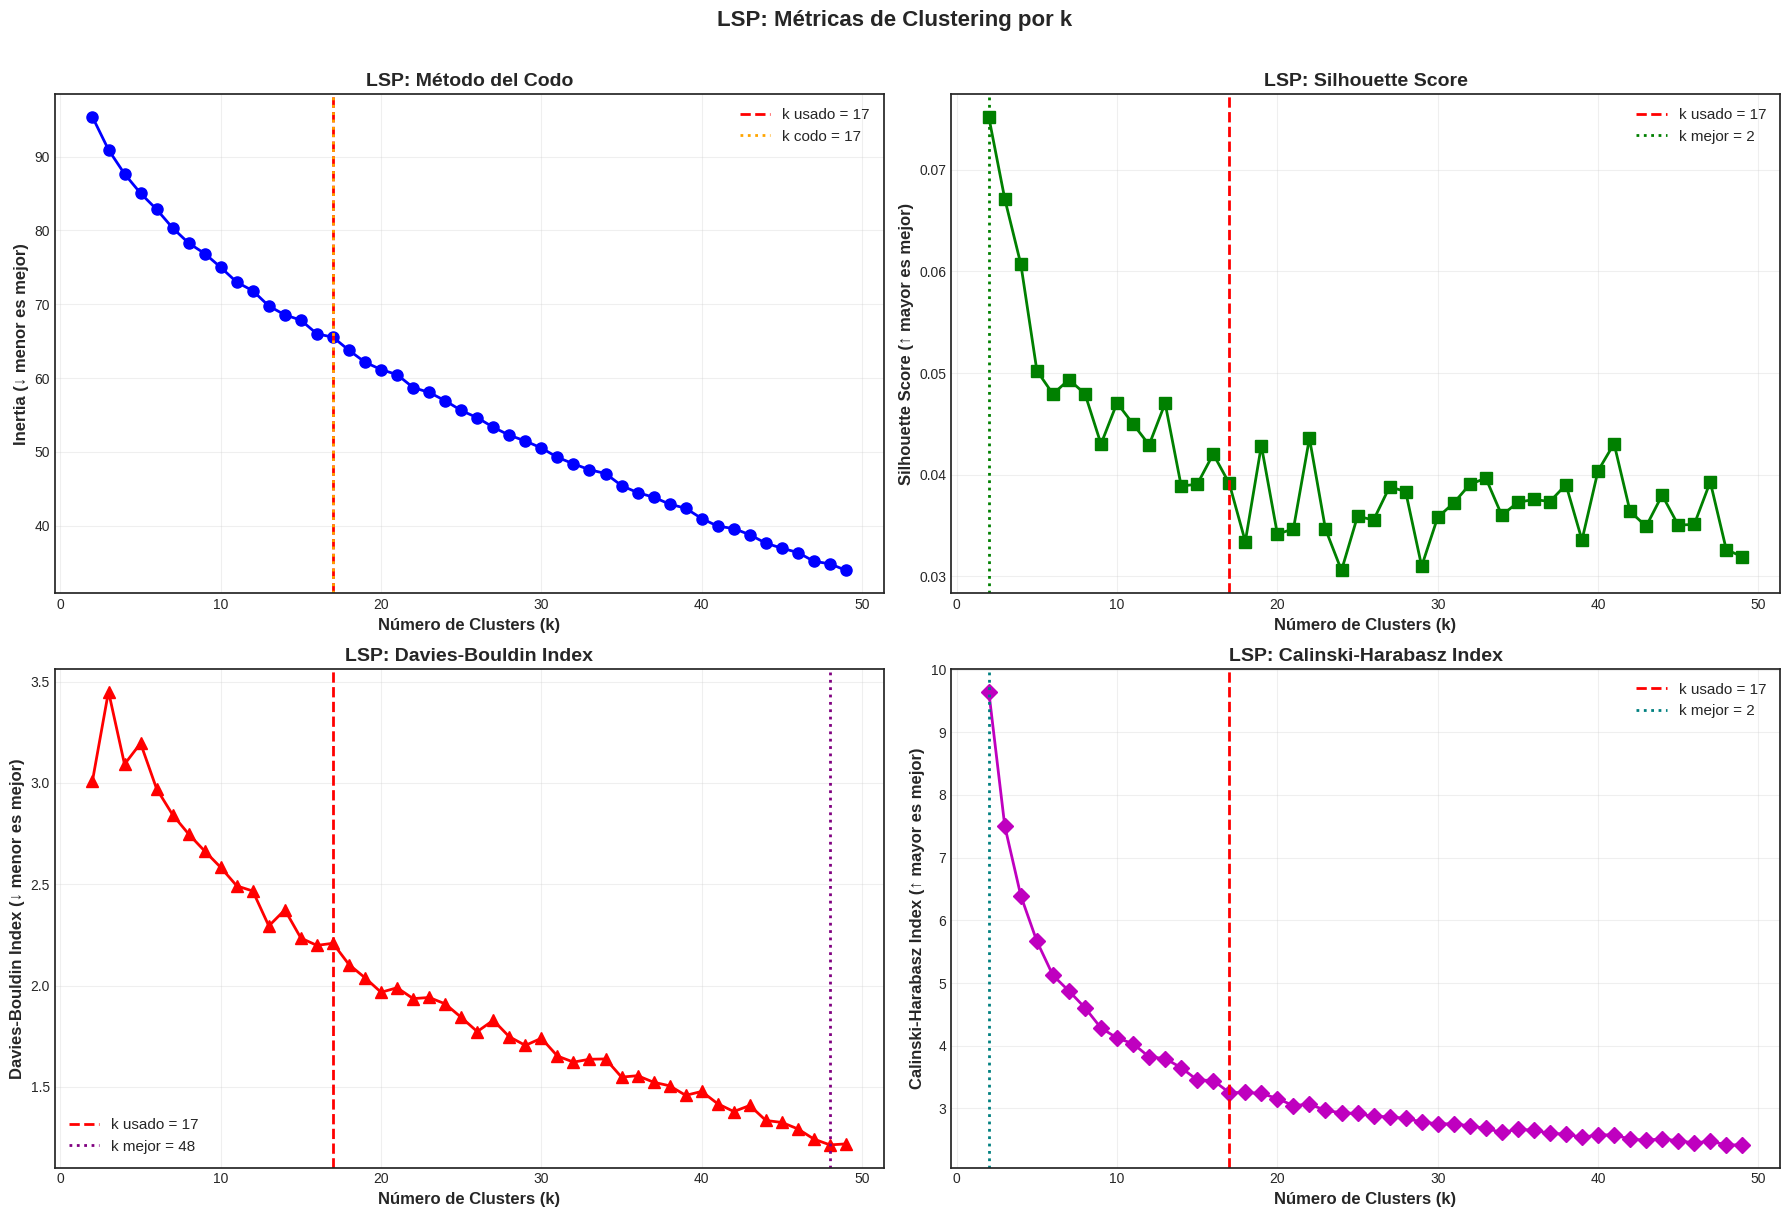

✅ Gráfica guardada: elbow.png

📊 Tabla de métricas por k:


,k,Inertia ↓,1ª Deriv (caída),2ª Deriv (curvatura),Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Notas
0,2,95.37,—,—,0.0752,3.0104,9.65,↑ Silhouette | ↑ Calinski-Harabasz
1,3,90.93,-4.4375,—,0.0671,3.4514,7.50,
2,4,87.66,-3.2683,1.1692,0.0607,3.0924,6.39,
3,5,85.03,-2.6299,0.6383,0.0502,3.1960,5.67,
4,6,82.86,-2.1703,0.4597,0.0479,2.9714,5.12,
5,7,80.34,-2.5260,-0.3557,0.0494,2.8431,4.87,
6,8,78.29,-2.0496,0.4764,0.0480,2.7477,4.61,
7,9,76.87,-1.4136,0.6360,0.0430,2.6639,4.28,
8,10,75.01,-1.8689,-0.4553,0.0471,2.5833,4.12,
9,11,73.00,-2.0092,-0.1404,0.0450,2.4922,4.03,


In [26]:
# ==============================================================================
#  MÉTODO ELBOW
# ==============================================================================

print("Elbow Method - K-MEANS PHONOLOGICAL ANALYSIS")
print("="*80)

force_rerun = True

if force_rerun or not os.path.exists(f"{fileName}/{fileName}_elbow_{reduct_method["methodReduction"]}.png"):
  # Aplicar método del codo
  k_range = range(2, 50)

  #inertias_asl, sil_asl, db_asl, ch_asl, _ = elbow_method(coords_asl, "ASL", k_range) # antes x_Asl_50 # k_opt_asl
  inertias_lsp, sil_lsp, db_lsp, ch_lsp, k_elbow = elbow_method(coords, signLanguage, k_range)

  k_list = list(k_range)
  k_best_sil = k_list[np.argmax(sil_lsp)]
  k_best_db  = k_list[np.argmin(db_lsp)]
  k_best_ch  = k_list[np.argmax(ch_lsp)]

  fig, axes = plt.subplots(2, 2, figsize=(18, 12))
  (ax1, ax2), (ax3, ax4) = axes

  # --- Panel 1: Inertia (Método del Codo) ---
  ax1.plot(k_list, inertias_lsp, 'bo-', linewidth=2, markersize=8)
  ax1.axvline(k_opt,   color='red',    linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax1.axvline(k_elbow, color='orange', linestyle=':',  linewidth=2, label=f'k codo = {k_elbow}')
  ax1.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax1.set_ylabel('Inertia (↓ menor es mejor)', fontsize=12, fontweight='bold')
  ax1.set_title(signLanguage + ': Método del Codo', fontsize=14, fontweight='bold')
  ax1.grid(True, alpha=0.3)
  ax1.legend(fontsize=11)

  # --- Panel 2: Silhouette Score ---
  ax2.plot(k_list, sil_lsp, 'gs-', linewidth=2, markersize=8)
  ax2.axvline(k_opt,       color='red',    linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax2.axvline(k_best_sil,  color='green',  linestyle=':',  linewidth=2, label=f'k mejor = {k_best_sil}')
  ax2.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax2.set_ylabel('Silhouette Score (↑ mayor es mejor)', fontsize=12, fontweight='bold')
  ax2.set_title(signLanguage + ': Silhouette Score', fontsize=14, fontweight='bold')
  ax2.grid(True, alpha=0.3)
  ax2.legend(fontsize=11)

  # --- Panel 3: Davies-Bouldin Index ---
  ax3.plot(k_list, db_lsp, 'r^-', linewidth=2, markersize=8)
  ax3.axvline(k_opt,      color='red',    linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax3.axvline(k_best_db,  color='purple', linestyle=':',  linewidth=2, label=f'k mejor = {k_best_db}')
  ax3.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax3.set_ylabel('Davies-Bouldin Index (↓ menor es mejor)', fontsize=12, fontweight='bold')
  ax3.set_title(signLanguage + ': Davies-Bouldin Index', fontsize=14, fontweight='bold')
  ax3.grid(True, alpha=0.3)
  ax3.legend(fontsize=11)

  # --- Panel 4: Calinski-Harabasz Index ---
  ax4.plot(k_list, ch_lsp, 'mD-', linewidth=2, markersize=8)
  ax4.axvline(k_opt,      color='red',  linestyle='--', linewidth=2, label=f'k usado = {k_opt}')
  ax4.axvline(k_best_ch,  color='teal', linestyle=':',  linewidth=2, label=f'k mejor = {k_best_ch}')
  ax4.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
  ax4.set_ylabel('Calinski-Harabasz Index (↑ mayor es mejor)', fontsize=12, fontweight='bold')
  ax4.set_title(signLanguage + ': Calinski-Harabasz Index', fontsize=14, fontweight='bold')
  ax4.grid(True, alpha=0.3)
  ax4.legend(fontsize=11)

# ----

  plt.suptitle(signLanguage + ': Métricas de Clustering por k',
               fontsize=16, fontweight='bold', y=1.01)

  plt.tight_layout()
  plt.savefig(f"{fileName}/{fileName}_elbow_{reduct_method['methodReduction']}.png",
              dpi=300, bbox_inches='tight', facecolor='white')

  plt.show()

  print("✅ Gráfica guardada: elbow.png")

  # --- Tabla comparativa de métricas por k ---
  print("\n📊 Tabla de métricas por k:")
  notas = []
  for k in k_list:
      n = []
      if k == k_opt:      n.append('★ k usado')
      if k == k_elbow:    n.append('↕ codo')
      if k == k_best_sil: n.append('↑ Silhouette')
      if k == k_best_db:  n.append('↓ Davies-Bouldin')
      if k == k_best_ch:  n.append('↑ Calinski-Harabasz')
      notas.append(' | '.join(n))


  # df_metrics = pd.DataFrame({
  #     'k':                       k_list,
  #     'Inertia ↓':               [round(v, 2)  for v in inertias_lsp],
  #     'Silhouette ↑':            [round(v, 4)  for v in sil_lsp],
  #     'Davies-Bouldin ↓':        [round(v, 4)  for v in db_lsp],
  #     'Calinski-Harabasz ↑':     [round(v, 2)  for v in ch_lsp],
  #     'Notas':                   notas
  # })


  # Derivadas de inercia para visualizar el codo
  inertias_arr     = np.array(inertias_lsp)
  first_deriv_col  = [None] + [round(v, 4) for v in np.diff(inertias_arr)]
  second_deriv_col = [None, None] + [round(v, 4) for v in np.diff(inertias_arr, n=2)]

  df_metrics = pd.DataFrame({
      'k':                       k_list,
      'Inertia ↓':               [round(v, 2)  for v in inertias_lsp],
      '1ª Deriv (caída)':        first_deriv_col,
      '2ª Deriv (curvatura)':    second_deriv_col,
      'Silhouette ↑':            [round(v, 4)  for v in sil_lsp],
      'Davies-Bouldin ↓':        [round(v, 4)  for v in db_lsp],
      'Calinski-Harabasz ↑':     [round(v, 2)  for v in ch_lsp],
      'Notas':                   notas
  })

  def highlight_k(row):
      k = row['k']
      if k == k_opt:      return ['background-color: #ffcccc'] * len(row)  # rojo:   k usado
      if k == k_elbow:    return ['background-color: #ffe0b2'] * len(row)  # naranja: codo
      if k == k_best_sil: return ['background-color: #c8e6c9'] * len(row)  # verde:   silhouette
      if k == k_best_db:  return ['background-color: #e1bee7'] * len(row)  # morado:  davies-bouldin
      if k == k_best_ch:  return ['background-color: #b2ebf2'] * len(row)  # cyan:    calinski-harabasz
      return [''] * len(row)

  caption = (
      f"Métricas K-Means  |  "
      f"🔴 k usado={k_opt}  |  "
      f"🟠 codo={k_elbow}  |  "
      f"🟢 mejor Silhouette={k_best_sil}  |  "
      f"🟣 mejor Davies-Bouldin={k_best_db}  |  "
      f"🔵 mejor Calinski-Harabasz={k_best_ch}")

  display(df_metrics.style
      .apply(highlight_k, axis=1)
      .set_caption(caption)
      .format({
          'Inertia ↓':           '{:.2f}',
          '1ª Deriv (caída)':    lambda v: f'{v:.4f}' if v is not None and not (isinstance(v, float) and np.isnan(v)) else '—',
          '2ª Deriv (curvatura)':lambda v: f'{v:.4f}' if v is not None and not (isinstance(v, float) and np.isnan(v)) else '—',
          'Silhouette ↑':        '{:.4f}',
          'Davies-Bouldin ↓':    '{:.4f}',
          'Calinski-Harabasz ↑': '{:.2f}',
      })
  )




In [27]:
coords.shape

(105, 50)

***********
PCA only inertia de 0 a 30

TSNE only inertia de 0 a 500,000

PCA_TSNE inertia de 0 a 400,000

Since inertia is literally the sum of squared distances to centroids, the t-SNE embedding produces meaningless or inflated inertia values.

La suma de los cuadrados de los errores (inertia) es más grande en ASL que en LSP.
**********

### **3. Apply K-Means , Analyze and Visualize**

In [28]:
# ==============================================================================
# Aplicar K-Means
# ==============================================================================
# asl_data = apply_kmeans(coords_asl, asl_data, k_opt_asl, "ASL") # antes X_asl_50
# sign_data = apply_kmeans(coords_lsp, sign_data, k_opt_lsp, "LSP")


sign_data = apply_kmeans(coords, sign_data, k_opt, signLanguage)

# Apply TSNE for plot
coords_tsne = apply_tsne(coords, signLanguage)

sign_data['tsne_x'] = coords_tsne[:, 0]
sign_data['tsne_y'] = coords_tsne[:, 1]





LSP con k=17:
   Clustering completado
   Silhouette Score: 0.039 (más cerca de 1 = mejor)
   Davies-Bouldin Index: 2.209 (más cerca de 0 = mejor)

   Distribución de señas por cluster:
      Cluster 0: 8 señas (7.6%) - Iconicidad media: 4.22
      Cluster 1: 6 señas (5.7%) - Iconicidad media: 4.41
      Cluster 2: 8 señas (7.6%) - Iconicidad media: 4.36
      Cluster 3: 10 señas (9.5%) - Iconicidad media: 4.23
      Cluster 4: 9 señas (8.6%) - Iconicidad media: 4.43
      Cluster 5: 7 señas (6.7%) - Iconicidad media: 4.42
      Cluster 6: 6 señas (5.7%) - Iconicidad media: 4.46
      Cluster 7: 6 señas (5.7%) - Iconicidad media: 4.29
      Cluster 8: 7 señas (6.7%) - Iconicidad media: 4.53
      Cluster 9: 6 señas (5.7%) - Iconicidad media: 4.30
      Cluster 10: 5 señas (4.8%) - Iconicidad media: 4.46
      Cluster 11: 4 señas (3.8%) - Iconicidad media: 4.68
      Cluster 12: 6 señas (5.7%) - Iconicidad media: 4.22
      Cluster 13: 4 señas (3.8%) - Iconicidad media: 4.66
      Clus

In [29]:
sign_data

,word,EnglishGloss,iconicity,0,1,2,3,4,5,6,...,253,254,255,icon_category,x,y,z,cluster,tsne_x,tsne_y
0,AVIÓN,PLANE,4.627451,0.055275,-0.108810,0.014533,0.041355,-0.088619,-0.130564,-0.018783,...,0.103949,0.016723,-0.000550,8,-0.401716,-0.189474,0.118532,1,-0.082663,2.896280
1,BALLENA,WHALE,3.823529,0.030203,0.083716,-0.024807,-0.152549,-0.051707,0.058088,0.078909,...,-0.009729,-0.050520,-0.074694,6,-0.113874,0.248177,-0.159864,7,2.634729,1.318871
2,BEBER,DRINK,4.745098,0.051722,0.116147,0.021334,0.065851,-0.121639,-0.048938,-0.027213,...,-0.024673,0.011873,-0.002671,8,-0.278978,0.284078,0.165471,1,2.441082,4.407288
3,BEBÉ,BABY,4.254902,-0.048735,-0.042702,0.118751,0.081172,0.093464,-0.018908,-0.079542,...,0.068677,-0.048424,0.038967,7,0.140516,0.102646,0.416833,3,4.744806,2.110460
4,BILLETE,BILL,3.960784,-0.038487,0.037250,-0.044018,-0.005553,-0.058923,0.000919,-0.073150,...,0.040218,0.010747,-0.022936,6,0.224020,-0.006771,-0.437408,0,3.187222,-2.571691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,VEHÍCULO-LARGO,LARGE-VEHICLE,3.882353,-0.013286,0.010156,-0.035889,0.067585,-0.018608,-0.013413,0.000421,...,-0.084000,-0.035856,0.039432,6,0.399376,0.130859,0.473304,3,6.004159,0.024865
101,VER,SEE,4.549020,0.047603,-0.009952,-0.005732,0.034065,-0.013871,0.092315,-0.047374,...,0.121950,0.020663,-0.066848,8,-0.221199,-0.572014,-0.195415,8,-1.512354,1.934982
102,VIEJO,OLD,4.274510,0.044409,0.045963,0.023768,-0.011563,-0.112801,-0.007945,0.016909,...,0.038084,-0.013480,0.079148,7,-0.535124,-0.138995,-0.362355,9,-1.664942,2.997905
103,VIENTO,WIND,4.529412,0.044835,-0.030418,0.056147,-0.049114,-0.015730,-0.004799,0.037965,...,0.132026,-0.066652,0.033116,8,0.060217,-0.323883,-0.045634,16,3.609892,-4.287605



🎨 VISUALIZACIÓN 1: CLUSTERS K-MEANS


📊 Generando gráfica para LSP...
   🔹 Etiquetando 105 señas...


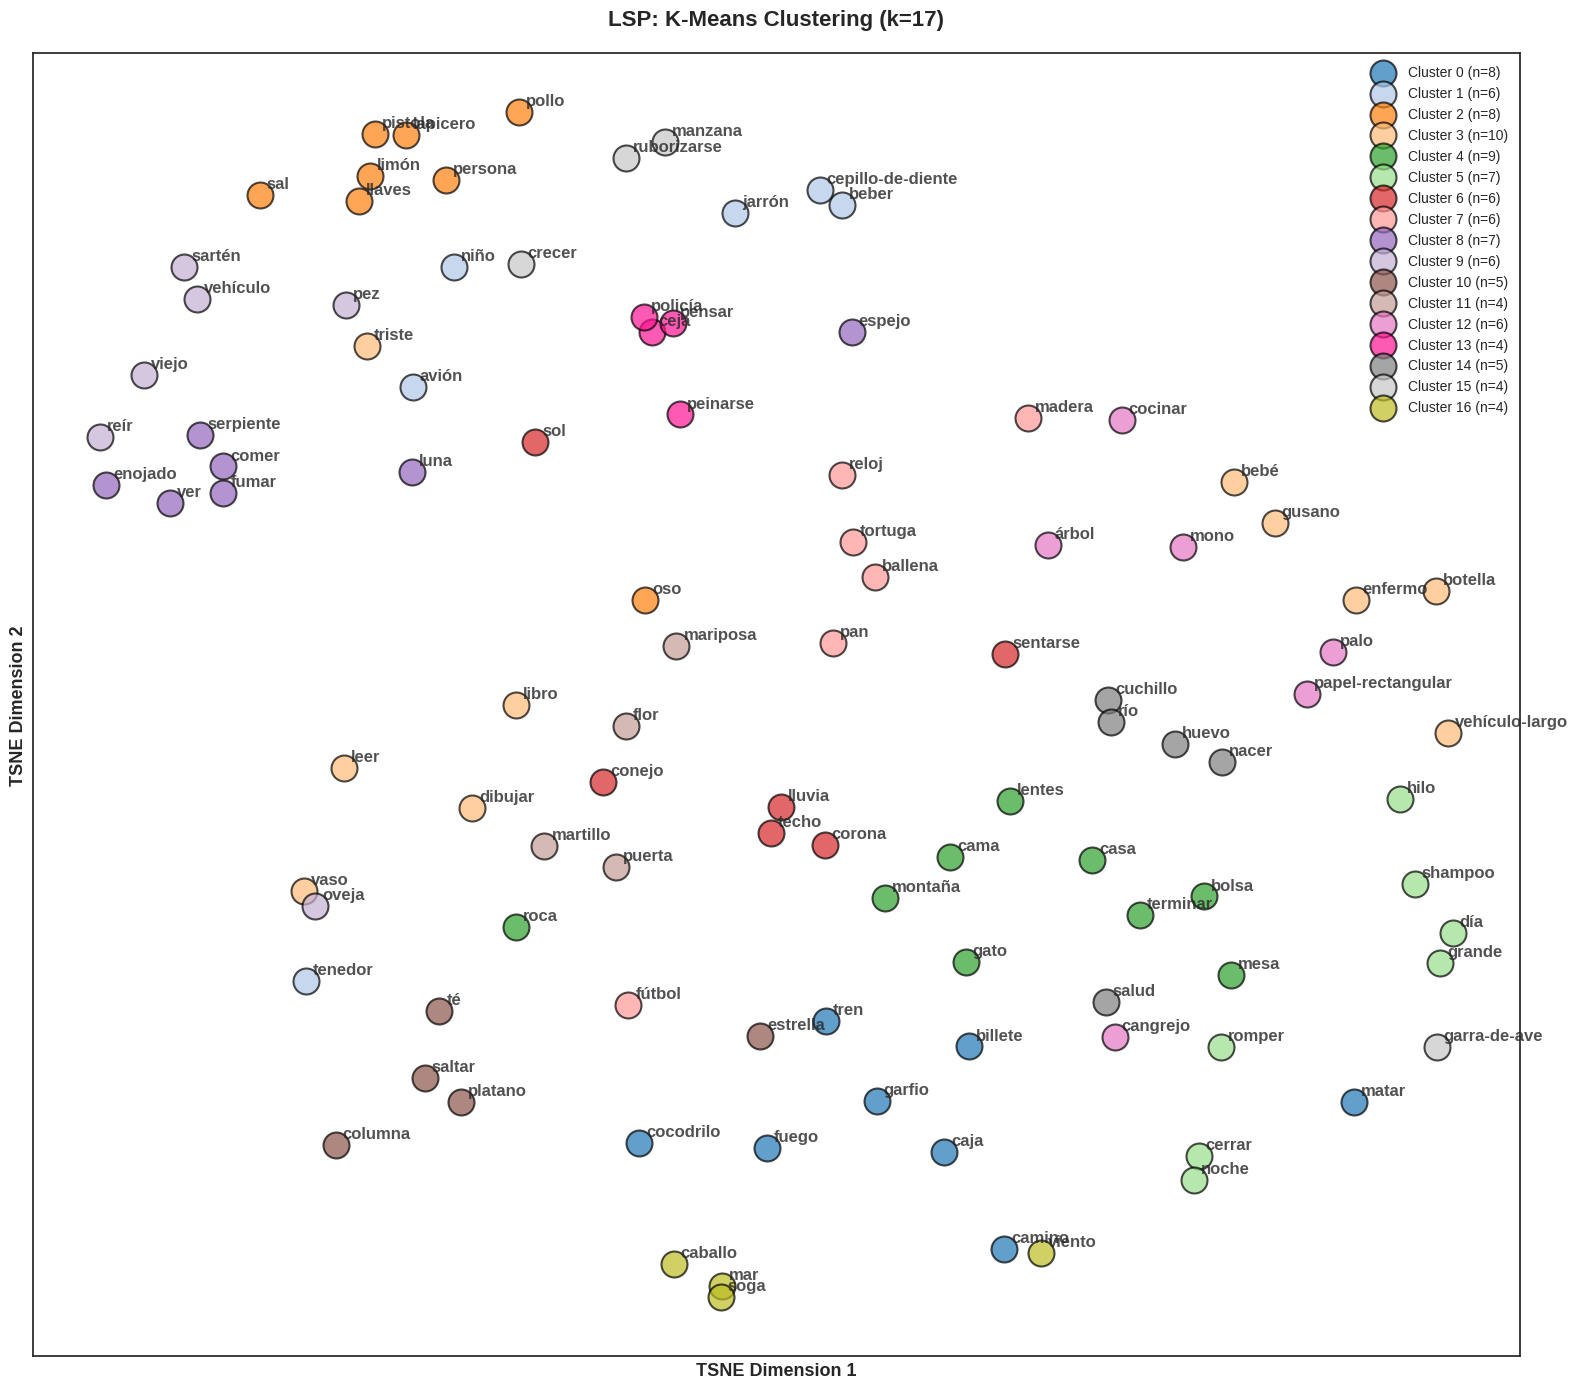

   ✅ emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_k17_PCA_TSNE.png guardada


In [30]:
# ==============================================================================
# VISUALIZACIÓN 1: CLUSTERS K-MEANS
# ==============================================================================

print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 1: CLUSTERS K-MEANS")
print("\n" + "="*80)

# Generar gráficas individuales
#plot_kmeans_clusters(asl_data, reduct_method, 'ASL', k_opt_asl, fileName[:-6]+'k'+str(k_opt_asl)+'_asl.png')
plot_kmeans_clusters(sign_data, signLanguage, k_opt, f"{fileName}/{fileName}_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")


🎨 VISUALIZACIÓN 2: CLUSTERS K-MEANS CON ETIQUETAS BLANCAS

📊 Generando gráfica para LSP...


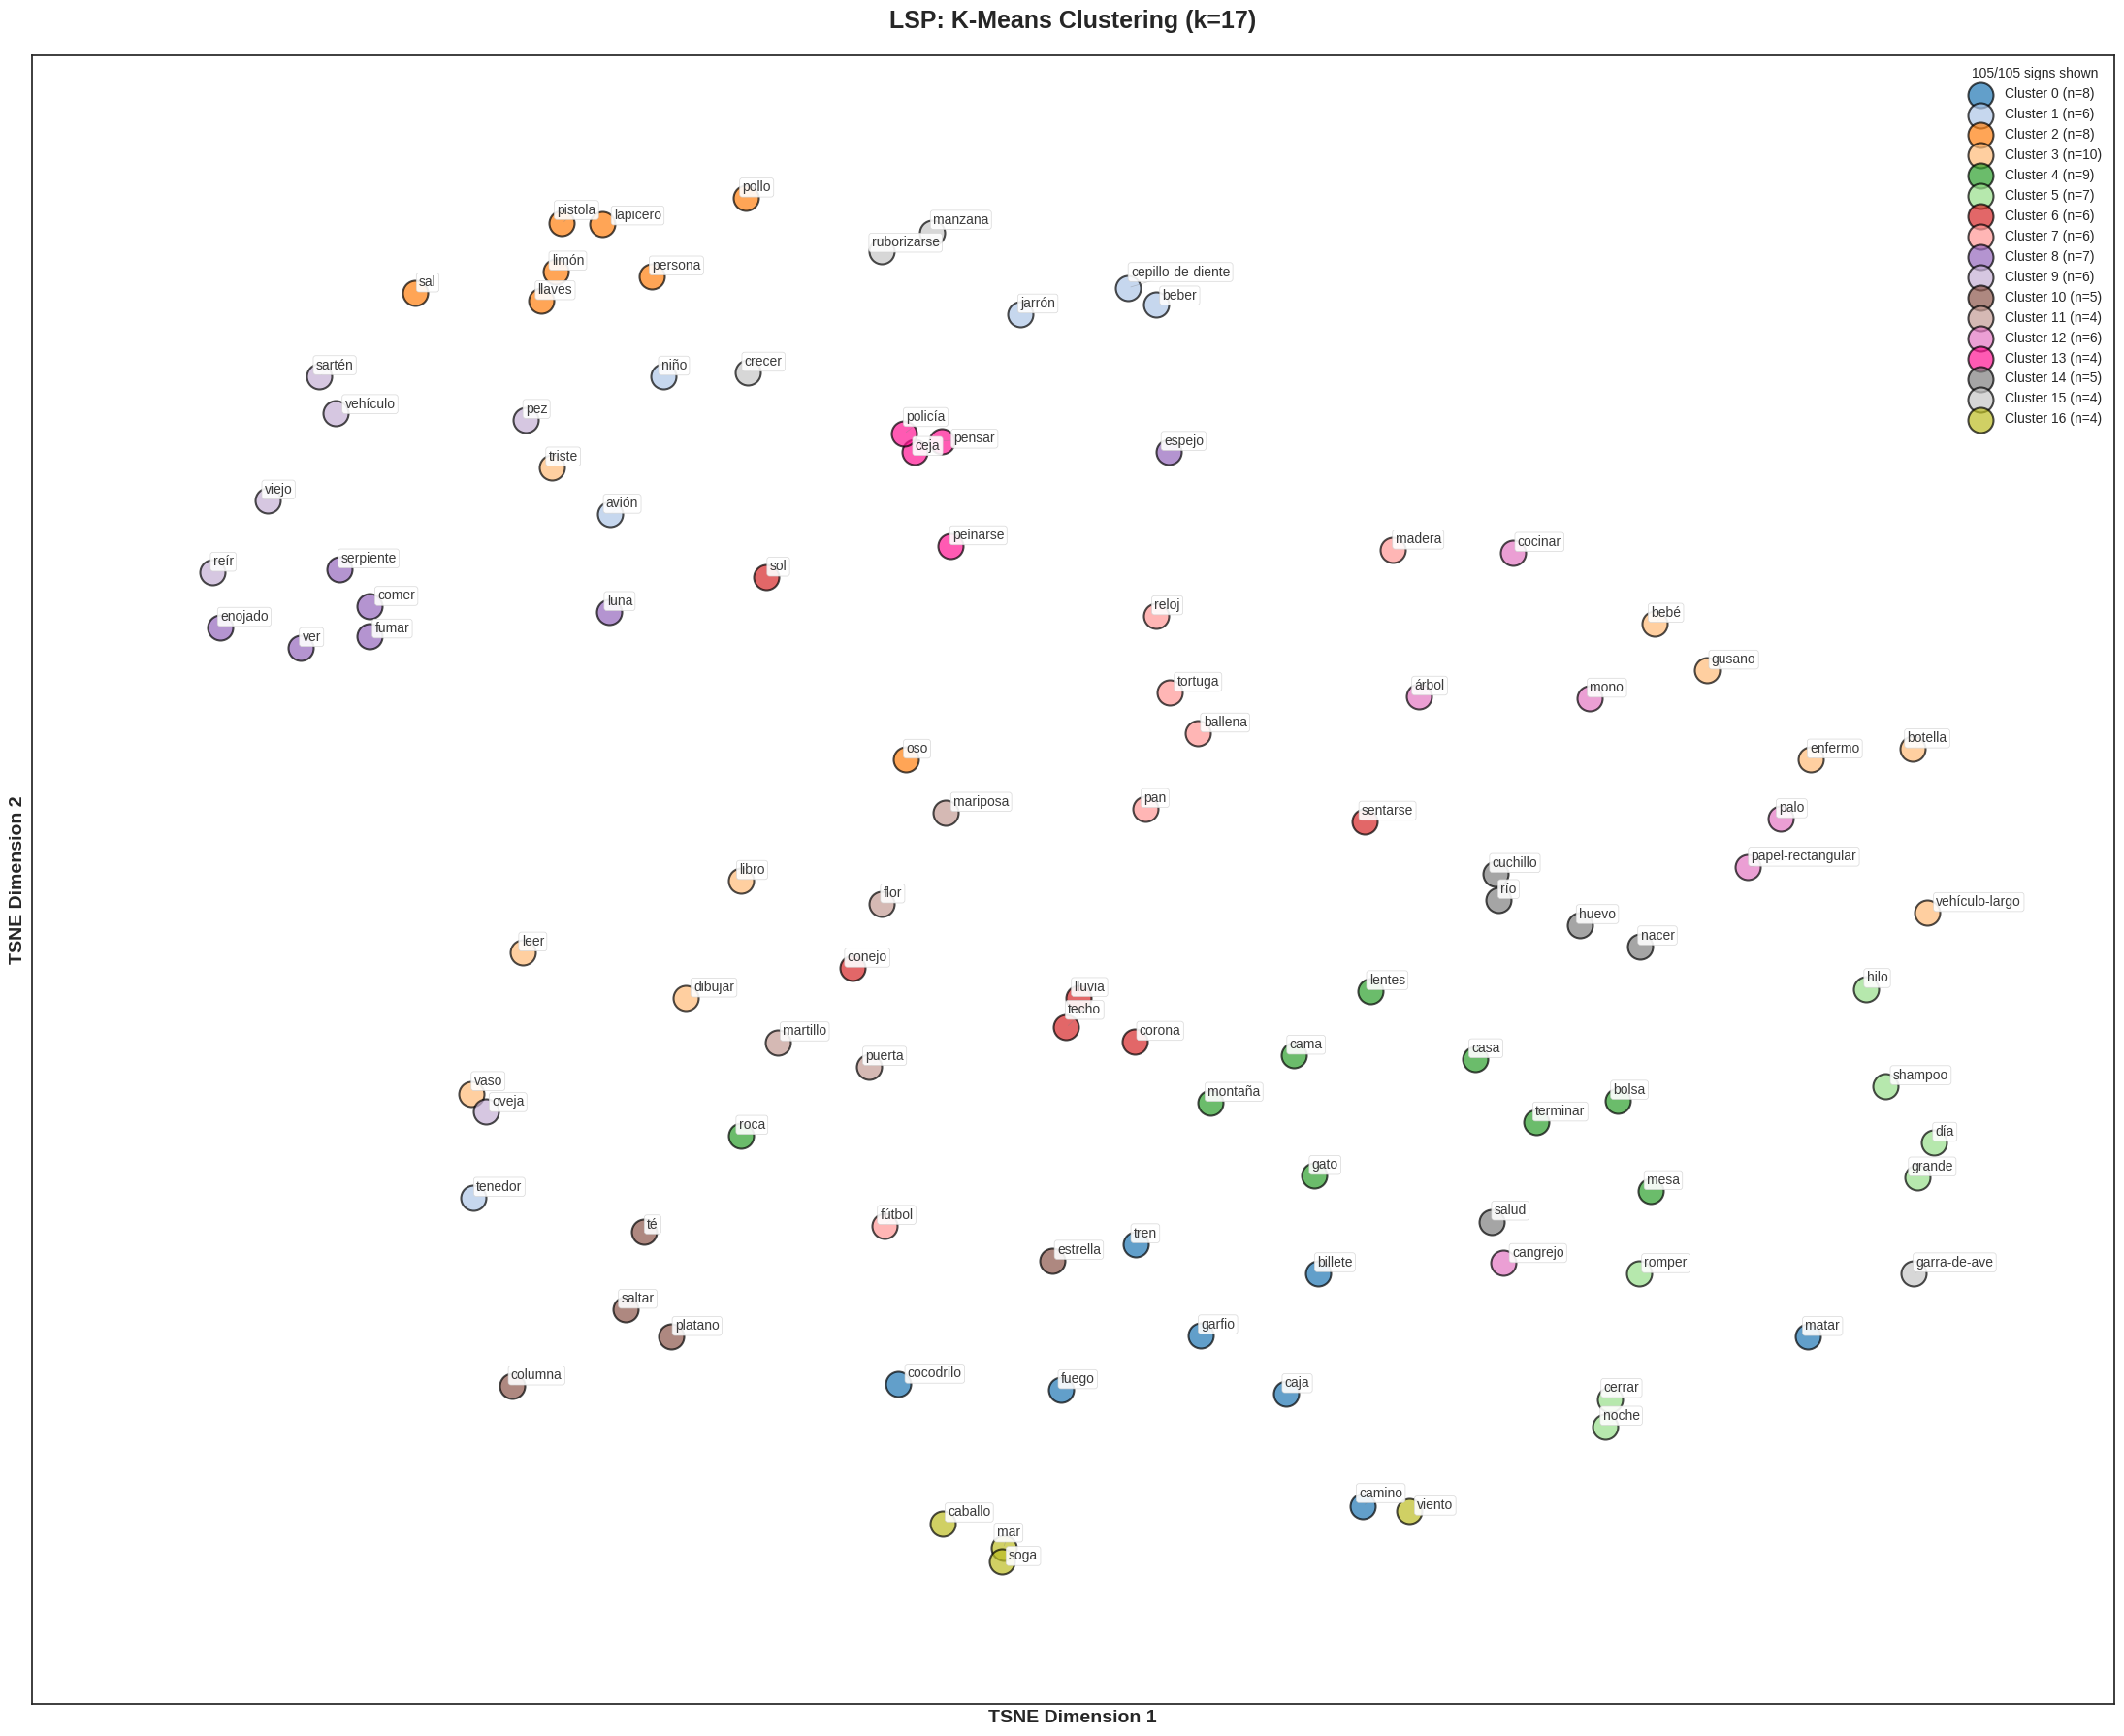

✅ emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_k17_PCA_TSNE.png guardada (105 etiquetas)


In [31]:
# ==============================================================================
# VISUALIZACIÓN 2: CLUSTERS K-MEANS CON ETIQUETAS BLANCAS
# ==============================================================================

print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 2: CLUSTERS K-MEANS CON ETIQUETAS BLANCAS")
# Generar gráficas individuales
#plot_kmeans_clusters(asl_data, reduct_method, 'ASL', k_opt_asl, fileName[:-6]+'k'+str(k_opt_asl)+'_asl.png')
plot_kmeans_clusters_new(sign_data, signLanguage, k_opt, f"{fileName}/{fileName}_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")


🎨 VISUALIZACIÓN 3: CLUSTERS K-MEANS  (COLOR) + ICONICIDAD (TAMAÑO)


📊 Generando gráfica para LSP...
   🔹 Etiquetando 105 señas...


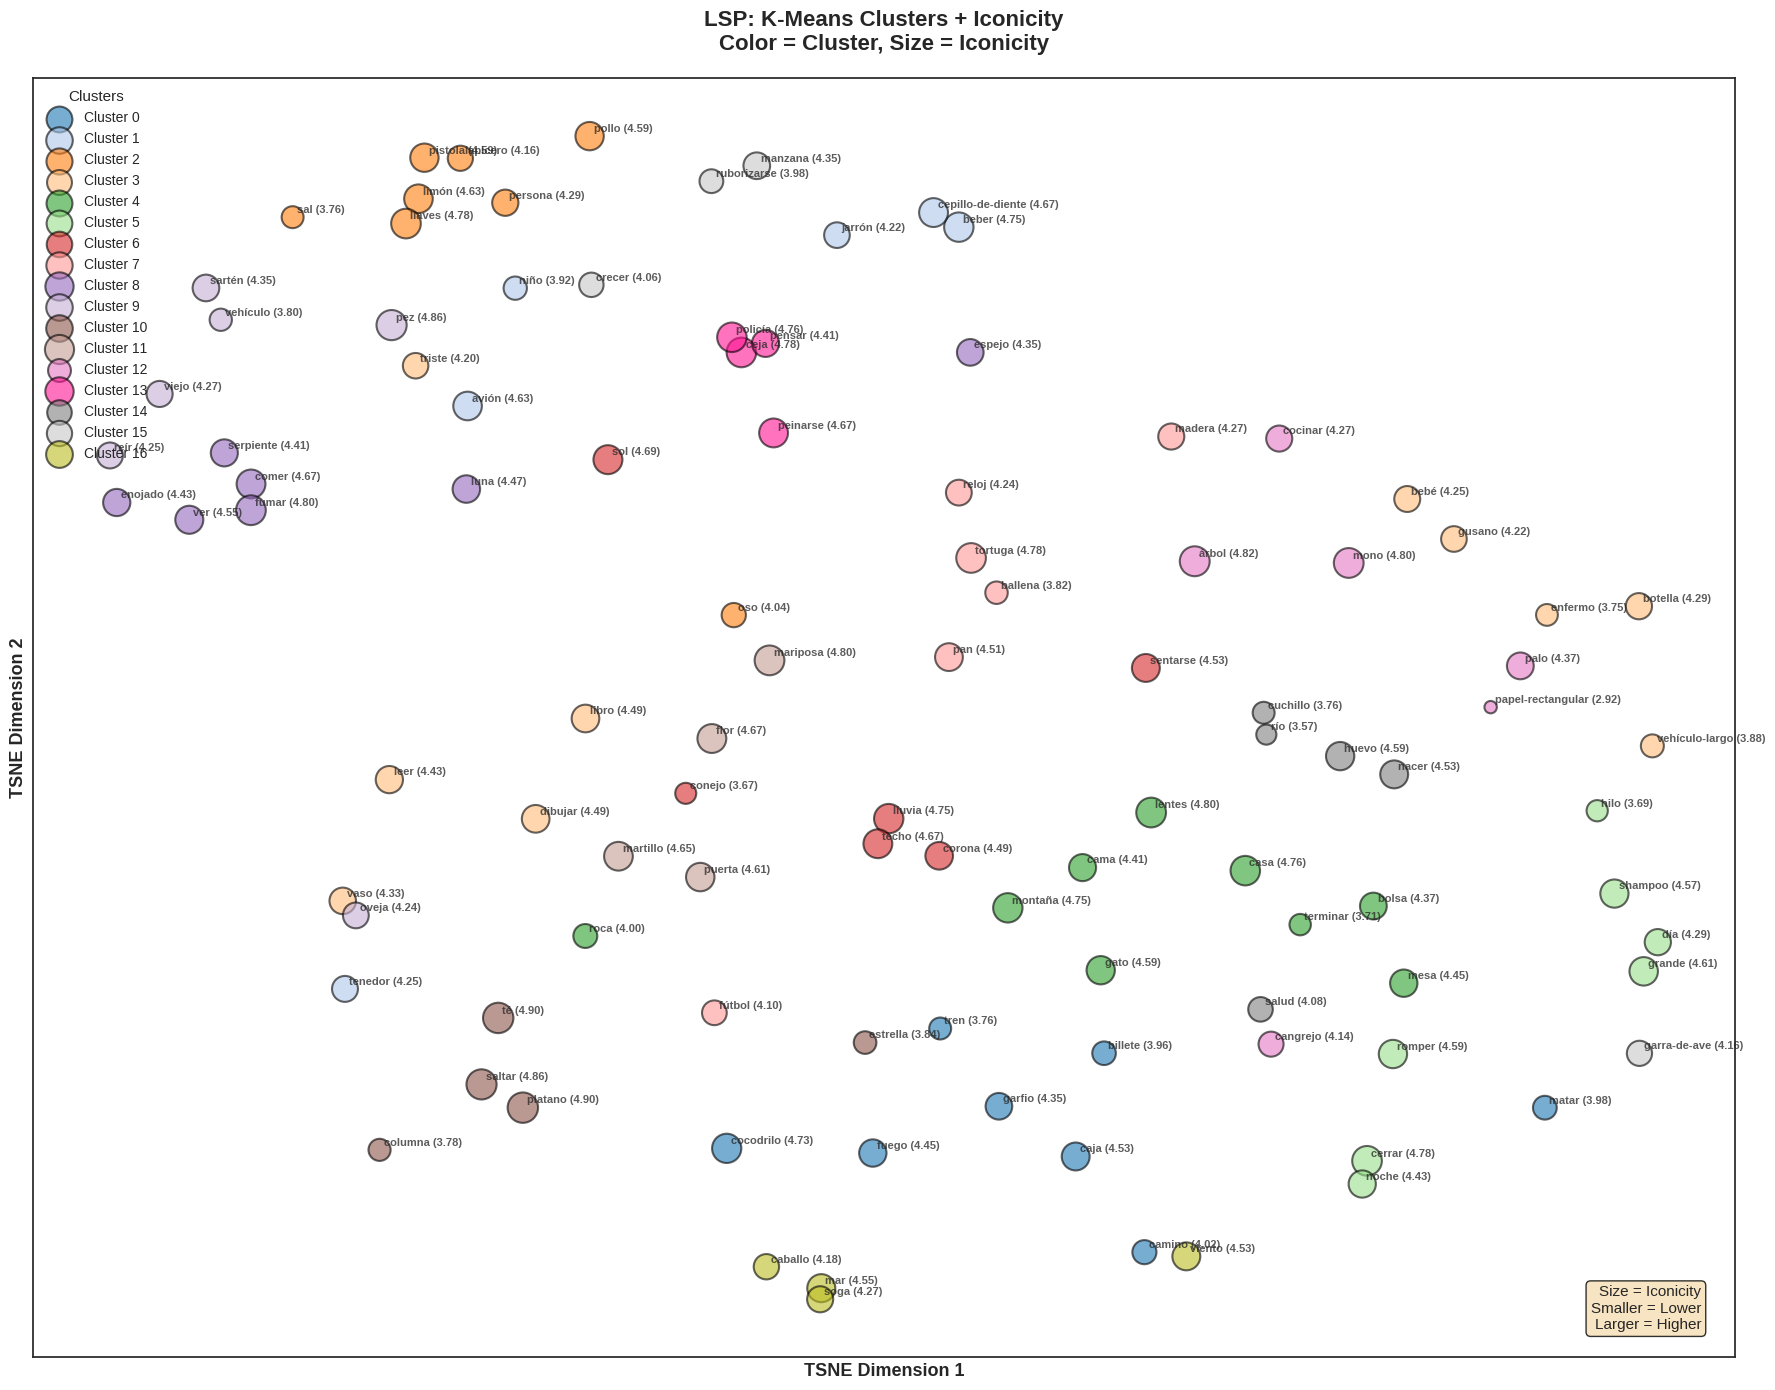

 emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_iconSize_k17_PCA_TSNE.png guardada


In [32]:
# ==============================================================================
# VISUALIZACIÓN 3: CLUSTERS K-MEANS  (COLOR) + ICONICIDAD (TAMAÑO)
# ==============================================================================

print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 3: CLUSTERS K-MEANS  (COLOR) + ICONICIDAD (TAMAÑO)")
print("\n" + "="*80)

# Generar gráficas

plot_clusters_iconicity_size(sign_data, signLanguage, k_opt, f"{fileName}/{fileName}_iconSize_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")



🎨 VISUALIZACIÓN 4: FACET GRID POR CLUSTER

 Generando facet grid para LSP...
 Cluster 0: Etiquetando 8 señas...
 Cluster 1: Etiquetando 6 señas...
 Cluster 2: Etiquetando 8 señas...
 Cluster 3: Etiquetando 10 señas...
 Cluster 4: Etiquetando 9 señas...
 Cluster 5: Etiquetando 7 señas...
 Cluster 6: Etiquetando 6 señas...
 Cluster 7: Etiquetando 6 señas...
 Cluster 8: Etiquetando 7 señas...
 Cluster 9: Etiquetando 6 señas...
 Cluster 10: Etiquetando 5 señas...
 Cluster 11: Etiquetando 4 señas...
 Cluster 12: Etiquetando 6 señas...
 Cluster 13: Etiquetando 4 señas...
 Cluster 14: Etiquetando 5 señas...
 Cluster 15: Etiquetando 4 señas...
 Cluster 16: Etiquetando 4 señas...


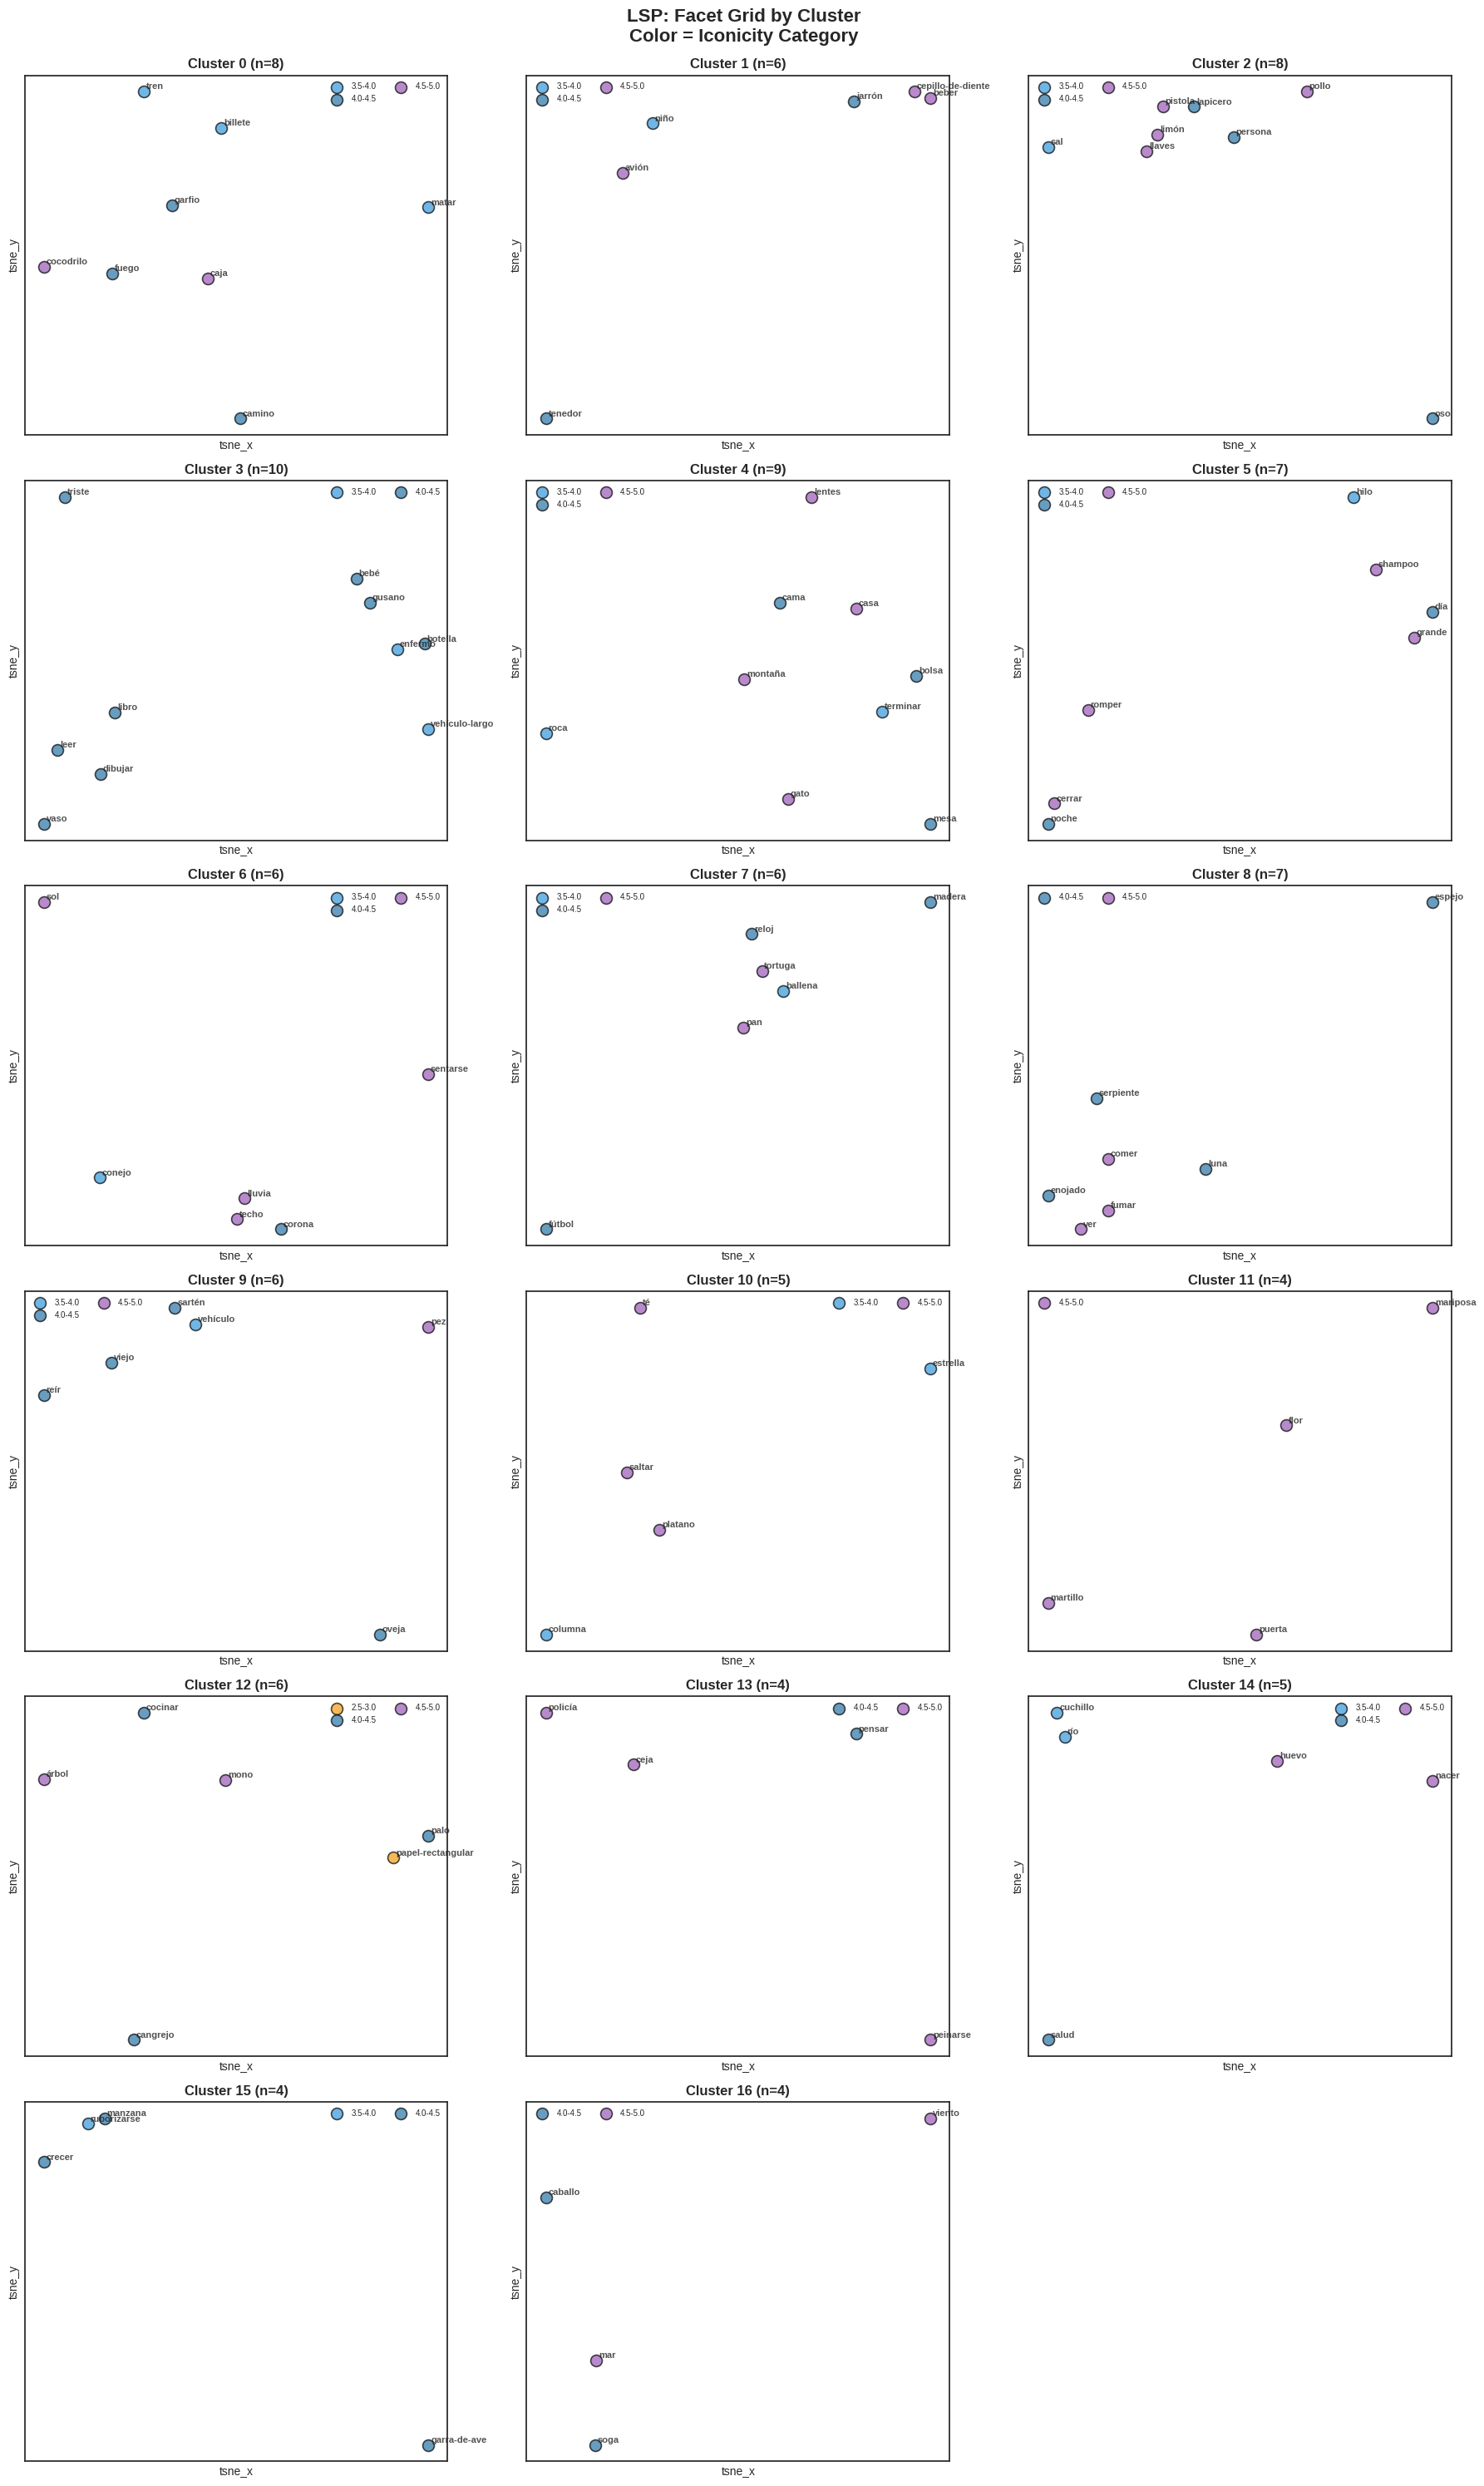

emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_gridBy_k17_PCA_TSNE.png guardada


In [33]:
# ==============================================================================
# VISUALIZACIÓN 4: FACET GRID (SUBPLOT POR CLUSTER)
# ==============================================================================
print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 4: FACET GRID POR CLUSTER")
# Generar facet grids
#plot_facet_grid_clusters(asl_data, 'ASL', k_opt_asl, fileName[:-6]+'gridBy_k'+k_opt_asl+'_asl.png')

plot_facet_grid_clusters(sign_data,signLanguage, k_opt, f"{fileName}/{fileName}_gridBy_k{str(k_opt)}_{reduct_method["methodReduction"]}.png")


In [34]:

# ==============================================================================
# ESTADÍSTICAS DETALLADAS POR CLUSTER
# ==============================================================================

print("\n" + "="*80)
print("ESTADÍSTICAS DETALLADAS POR CLUSTER")
print("="*80)

# Analizar clusters
#stats_asl = analyze_clusters(asl_data, signLanguage, k_opt_asl)
stats_lsp = analyze_clusters(sign_data, signLanguage, k_opt)

# Guardar estadísticas
with open(f"{fileName}/{fileName}_{reduct_method["methodReduction"]}_cluster_statistics.txt", 'w', encoding='utf-8') as f:
    f.write(stats_lsp)

print("\n Estadísticas guardadas en: cluster_statistics.txt")



ESTADÍSTICAS DETALLADAS POR CLUSTER

LSP - ANÁLISIS DE CLUSTERS (k=17)

 CLUSTER 0:
   • Tamaño: 8 señas (7.6%)
   • Iconicidad: 4.22 ± 0.34 (rango: 3.76 - 4.73)
   • Top 5 más icónicas:
      COCODRILO       → 4.73
      CAJA            → 4.53
      FUEGO           → 4.45
      GARFIO          → 4.35
      CAMINO          → 4.02
   • Todas las señas (8):
      BILLETE, CAJA, CAMINO, COCODRILO, FUEGO, GARFIO, MATAR, TREN

 CLUSTER 1:
   • Tamaño: 6 señas (5.7%)
   • Iconicidad: 4.41 ± 0.32 (rango: 3.92 - 4.75)
   • Top 5 más icónicas:
      BEBER           → 4.75
      CEPILLO-DE-DIENTE → 4.67
      AVIÓN           → 4.63
      TENEDOR         → 4.25
      JARRÓN          → 4.22
   • Todas las señas (6):
      AVIÓN, BEBER, CEPILLO-DE-DIENTE, JARRÓN, NIÑO, TENEDOR

 CLUSTER 2:
   • Tamaño: 8 señas (7.6%)
   • Iconicidad: 4.36 ± 0.35 (rango: 3.76 - 4.78)
   • Top 5 más icónicas:
      LLAVES          → 4.78
      LIMÓN           → 4.63
      PISTOLA         → 4.59
      POLLO          

In [35]:
# ==============================================================================
# DISTANCIA AL CENTROIDE Y COHESIÓN POR CLUSTER
# ==============================================================================
print("\n" + "="*80)
print("DISTANCIA AL CENTROIDE — Cohesión de clusters")
print("="*80)

# Re-ajustar KMeans con mismo k y seed para obtener centroides
kmeans_final = KMeans(n_clusters=k_opt, n_init=50, max_iter=500, random_state=42)
kmeans_final.fit(coords)
centroids = kmeans_final.cluster_centers_   # shape: (k_opt, 50)

# Distancia de cada seña a su centroide asignado (en espacio PCA-50)
labels = sign_data['cluster'].values
sign_data['dist_to_centroid'] = [
    round(np.linalg.norm(coords[i] - centroids[labels[i]]), 4)
    for i in range(len(labels))
]

# --- Tabla 1: distancia por seña ---
print("\nDistancia de cada seña a su centroide:")
df_dist = sign_data[['word', 'cluster', 'dist_to_centroid']].copy()
df_dist = df_dist.sort_values(['cluster', 'dist_to_centroid']).reset_index(drop=True)
display(df_dist.style
    .background_gradient(subset=['dist_to_centroid'], cmap='RdYlGn_r')
    .format({'dist_to_centroid': '{:.4f}'})
    .set_caption("Distancia al centroide — verde=seña más representativa, rojo=outlier")
)

# --- Tabla 2: cohesión por cluster ---
print("\nCohesión por cluster:")
cohesion_rows = []
for c in range(k_opt):
    mask = sign_data['cluster'] == c
    dists_c = sign_data.loc[mask, 'dist_to_centroid']
    idx_min = dists_c.idxmin()
    idx_max = dists_c.idxmax()
    cohesion_rows.append({
        'Cluster':          c,
        'N señas':          int(mask.sum()),
        'Dist media ↓':     round(dists_c.mean(), 4),
        'Std ↓':            round(dists_c.std(),  4),
        'Dist min':         round(dists_c.min(),  4),
        'Dist max':         round(dists_c.max(),  4),
        'Seña + cercana':   sign_data.loc[idx_min, 'word'],
        'Seña + lejana':    sign_data.loc[idx_max, 'word'],
    })

df_cohesion = pd.DataFrame(cohesion_rows)
display(df_cohesion.style
    .background_gradient(subset=['Dist media ↓', 'Std ↓'], cmap='RdYlGn_r')
    .format({'Dist media ↓': '{:.4f}', 'Std ↓': '{:.4f}',
             'Dist min': '{:.4f}', 'Dist max': '{:.4f}'})
    .set_caption("Cohesión: Dist media ↓ pequeña = cluster más unido/compacto")
)



DISTANCIA AL CENTROIDE — Cohesión de clusters

Distancia de cada seña a su centroide:


,word,cluster,dist_to_centroid
0,FUEGO,0,0.6834
1,BILLETE,0,0.7677
2,GARFIO,0,0.8073
3,TREN,0,0.8171
4,CAJA,0,0.8437
5,CAMINO,0,0.8625
6,COCODRILO,0,0.8949
7,MATAR,0,0.9897
8,CEPILLO-DE-DIENTE,1,0.6388
9,AVIÓN,1,0.7777



Cohesión por cluster:


,Cluster,N señas,Dist media ↓,Std ↓,Dist min,Dist max,Seña + cercana,Seña + lejana
0,0,8,0.8333,0.0902,0.6834,0.9897,FUEGO,MATAR
1,1,6,0.7829,0.0852,0.6388,0.9049,CEPILLO-DE-DIENTE,TENEDOR
2,2,8,0.7741,0.1197,0.6029,0.9862,LAPICERO,OSO
3,3,10,0.8541,0.0912,0.6248,0.9638,GUSANO,VEHÍCULO-LARGO
4,4,9,0.8397,0.0872,0.6433,0.9386,CASA,MESA
5,5,7,0.8034,0.1011,0.6631,0.9709,GRANDE,SHAMPOO
6,6,6,0.7910,0.1057,0.6177,0.9424,LLUVIA,SENTARSE
7,7,6,0.7814,0.0964,0.6463,0.9030,BALLENA,PAN
8,8,7,0.7820,0.1091,0.6270,0.9049,VER,LUNA
9,9,6,0.7538,0.1059,0.6369,0.9309,VIEJO,OVEJA


In [36]:
# # ==============================================================================
# #  CLUSTERING JERÁRQUICO INTERNO
# # ==============================================================================

# print("HIERARCHICAL CLUSTERING — Internal Analysis per Cluster")
# print("="*80)

# resultados_jerarquicos = {}

# for cluster_id in [0,1,2,3]:
#     print(f"\n{'='*60}")
#     print(f"  CLUSTER GLOBAL {cluster_id} — Análisis interno")
#     print(f"{'='*60}")

#     # --- Filtrar datos del cluster ---
#     mask = sign_data['cluster'] == cluster_id
#     coords_sub = coords[mask]
#     data_sub = sign_data[mask].copy().reset_index(drop=True)
#     label = f"{signLanguage}_Cluster{cluster_id}"
#     n_sub = len(data_sub)

#     print(f"  N señas: {n_sub}")
#     print(f"  Señas: {', '.join(data_sub['word'].tolist())}")

#     # --- Elbow method interno ---
#     k_range_sub = range(2, min(n_sub // 3, 12))
#     inertias_sub, sil_sub, db_sub, ch_sub, k_elbow_sub = elbow_method(
#         coords_sub, label, k_range_sub
#     )
#     k_list_sub     = list(k_range_sub)
#     k_best_sil_sub = k_list_sub[np.argmax(sil_sub)]
#     k_best_db_sub  = k_list_sub[np.argmin(db_sub)]
#     k_best_ch_sub  = k_list_sub[np.argmax(ch_sub)]
#     # k_opt_sub      = k_best_sil_sub  # criterio principal: Silhouette
#     k_opt_sub      = 3

#     print(f"\n  k seleccionado para sub-clustering: {k_opt_sub}")

#     # --- Gráfica 4 paneles de métricas ---
#     fig, axes = plt.subplots(2, 2, figsize=(16, 10))
#     (ax1, ax2), (ax3, ax4) = axes

#     ax1.plot(k_list_sub, inertias_sub, 'bo-', linewidth=2, markersize=8)
#     ax1.axvline(k_opt_sub,    color='red',    linestyle='--', linewidth=2, label=f'k óptimo = {k_opt_sub}')
#     ax1.axvline(k_elbow_sub,  color='orange', linestyle=':',  linewidth=2, label=f'k codo = {k_elbow_sub}')
#     ax1.set_xlabel('k', fontsize=11, fontweight='bold')
#     ax1.set_ylabel('Inertia ↓', fontsize=11, fontweight='bold')
#     ax1.set_title('Método del Codo', fontsize=12, fontweight='bold')
#     ax1.grid(True, alpha=0.3)
#     ax1.legend(fontsize=10)

#     ax2.plot(k_list_sub, sil_sub, 'gs-', linewidth=2, markersize=8)
#     ax2.axvline(k_opt_sub,      color='red',   linestyle='--', linewidth=2, label=f'k óptimo = {k_opt_sub}')
#     ax2.axvline(k_best_sil_sub, color='green', linestyle=':',  linewidth=2, label=f'k mejor = {k_best_sil_sub}')
#     ax2.set_xlabel('k', fontsize=11, fontweight='bold')
#     ax2.set_ylabel('Silhouette ↑', fontsize=11, fontweight='bold')
#     ax2.set_title('Silhouette Score', fontsize=12, fontweight='bold')
#     ax2.grid(True, alpha=0.3)
#     ax2.legend(fontsize=10)

#     ax3.plot(k_list_sub, db_sub, 'r^-', linewidth=2, markersize=8)
#     ax3.axvline(k_opt_sub,     color='red',    linestyle='--', linewidth=2, label=f'k óptimo = {k_opt_sub}')
#     ax3.axvline(k_best_db_sub, color='purple', linestyle=':',  linewidth=2, label=f'k mejor = {k_best_db_sub}')
#     ax3.set_xlabel('k', fontsize=11, fontweight='bold')
#     ax3.set_ylabel('Davies-Bouldin ↓', fontsize=11, fontweight='bold')
#     ax3.set_title('Davies-Bouldin Index', fontsize=12, fontweight='bold')
#     ax3.grid(True, alpha=0.3)
#     ax3.legend(fontsize=10)

#     ax4.plot(k_list_sub, ch_sub, 'mD-', linewidth=2, markersize=8)
#     ax4.axvline(k_opt_sub,     color='red',  linestyle='--', linewidth=2, label=f'k óptimo = {k_opt_sub}')
#     ax4.axvline(k_best_ch_sub, color='teal', linestyle=':',  linewidth=2, label=f'k mejor = {k_best_ch_sub}')
#     ax4.set_xlabel('k', fontsize=11, fontweight='bold')
#     ax4.set_ylabel('Calinski-Harabasz ↑', fontsize=11, fontweight='bold')
#     ax4.set_title('Calinski-Harabasz Index', fontsize=12, fontweight='bold')
#     ax4.grid(True, alpha=0.3)
#     ax4.legend(fontsize=10)

#     plt.suptitle(f"{label}: Internal Clustering Metrics",
#                  fontsize=14, fontweight='bold', y=1.01)
#     plt.tight_layout()
#     plt.savefig(f"{fileName}/{fileName}_hierarchical_C{cluster_id}_elbow.png",
#                 dpi=300, bbox_inches='tight', facecolor='white')
#     plt.show()

#     # --- Tabla de métricas internas ---
#     notas_sub = []
#     for k in k_list_sub:
#         n = []
#         if k == k_opt_sub:      n.append('★ k usado')
#         if k == k_elbow_sub:    n.append('↕ codo')
#         if k == k_best_sil_sub: n.append('↑ Silhouette')
#         if k == k_best_db_sub:  n.append('↓ Davies-Bouldin')
#         if k == k_best_ch_sub:  n.append('↑ Calinski-Harabasz')
#         notas_sub.append(' | '.join(n))

#     df_sub = pd.DataFrame({
#         'k':                   k_list_sub,
#         'Inertia ↓':           [round(v, 2)  for v in inertias_sub],
#         'Silhouette ↑':        [round(v, 4)  for v in sil_sub],
#         'Davies-Bouldin ↓':    [round(v, 4)  for v in db_sub],
#         'Calinski-Harabasz ↑': [round(v, 2)  for v in ch_sub],
#         'Notas':               notas_sub
#     })

#     def highlight_sub(row):
#         if row['k'] == k_opt_sub:      return ['background-color: #ffcccc'] * len(row)
#         if row['k'] == k_elbow_sub:    return ['background-color: #ffe0b2'] * len(row)
#         if row['k'] == k_best_sil_sub: return ['background-color: #c8e6c9'] * len(row)
#         if row['k'] == k_best_db_sub:  return ['background-color: #e1bee7'] * len(row)
#         if row['k'] == k_best_ch_sub:  return ['background-color: #b2ebf2'] * len(row)
#         return [''] * len(row)

#     display(df_sub.style
#         .apply(highlight_sub, axis=1)
#         .set_caption(f"{label} — Métricas internas por k")
#         .format({'Inertia ↓': '{:.2f}', 'Silhouette ↑': '{:.4f}',
#                  'Davies-Bouldin ↓': '{:.4f}', 'Calinski-Harabasz ↑': '{:.2f}'})
#     )

#     # --- Aplicar clustering con k óptimo ---
#     data_sub = apply_kmeans(coords_sub, data_sub, k_opt_sub, label)

#     # --- T-SNE para visualización interna ---
#     coords_tsne_sub = apply_tsne(coords_sub, label)
#     data_sub['tsne_x'] = coords_tsne_sub[:, 0]
#     data_sub['tsne_y'] = coords_tsne_sub[:, 1]

#     # --- Scatter de sub-clusters ---
#     plot_kmeans_clusters_new(
#         data_sub, label, k_opt_sub,
#         f"{fileName}/{fileName}_hierarchical_C{cluster_id}_scatter.png"
#     )

#     # --- Guardar resultados ---
#     resultados_jerarquicos[cluster_id] = {
#         'data':   data_sub,
#         'k_opt':  k_opt_sub,
#         'n':      n_sub,
#         'sil':    silhouette_score(coords_sub, data_sub['cluster'].values),
#         'db':     davies_bouldin_score(coords_sub, data_sub['cluster'].values)
#     }

# # --- Tabla resumen jerárquica final ---
# print("\n" + "="*80)
# print("RESUMEN JERÁRQUICO COMPLETO")
# print("="*80)

# rows = []
# for cid, res in resultados_jerarquicos.items():
#     for sc in range(res['k_opt']):
#         subset = res['data'][res['data']['cluster'] == sc]
#         rows.append({
#             'Cluster global':    f"C{cid}  ({res['n']} señas)",
#             'Sub-cluster':       sc,
#             'N señas':           len(subset),
#             'Silhouette':        round(res['sil'], 4),
#             'Davies-Bouldin':    round(res['db'],  4),
#             'Señas (top 5)':     ', '.join(subset['word'].tolist()) + '...'
#         })

# display(pd.DataFrame(rows))



🎨 VISUALIZACIÓN 5: CLUSTERS IN 3D

📊 Generando gráfica 3D para LSP...


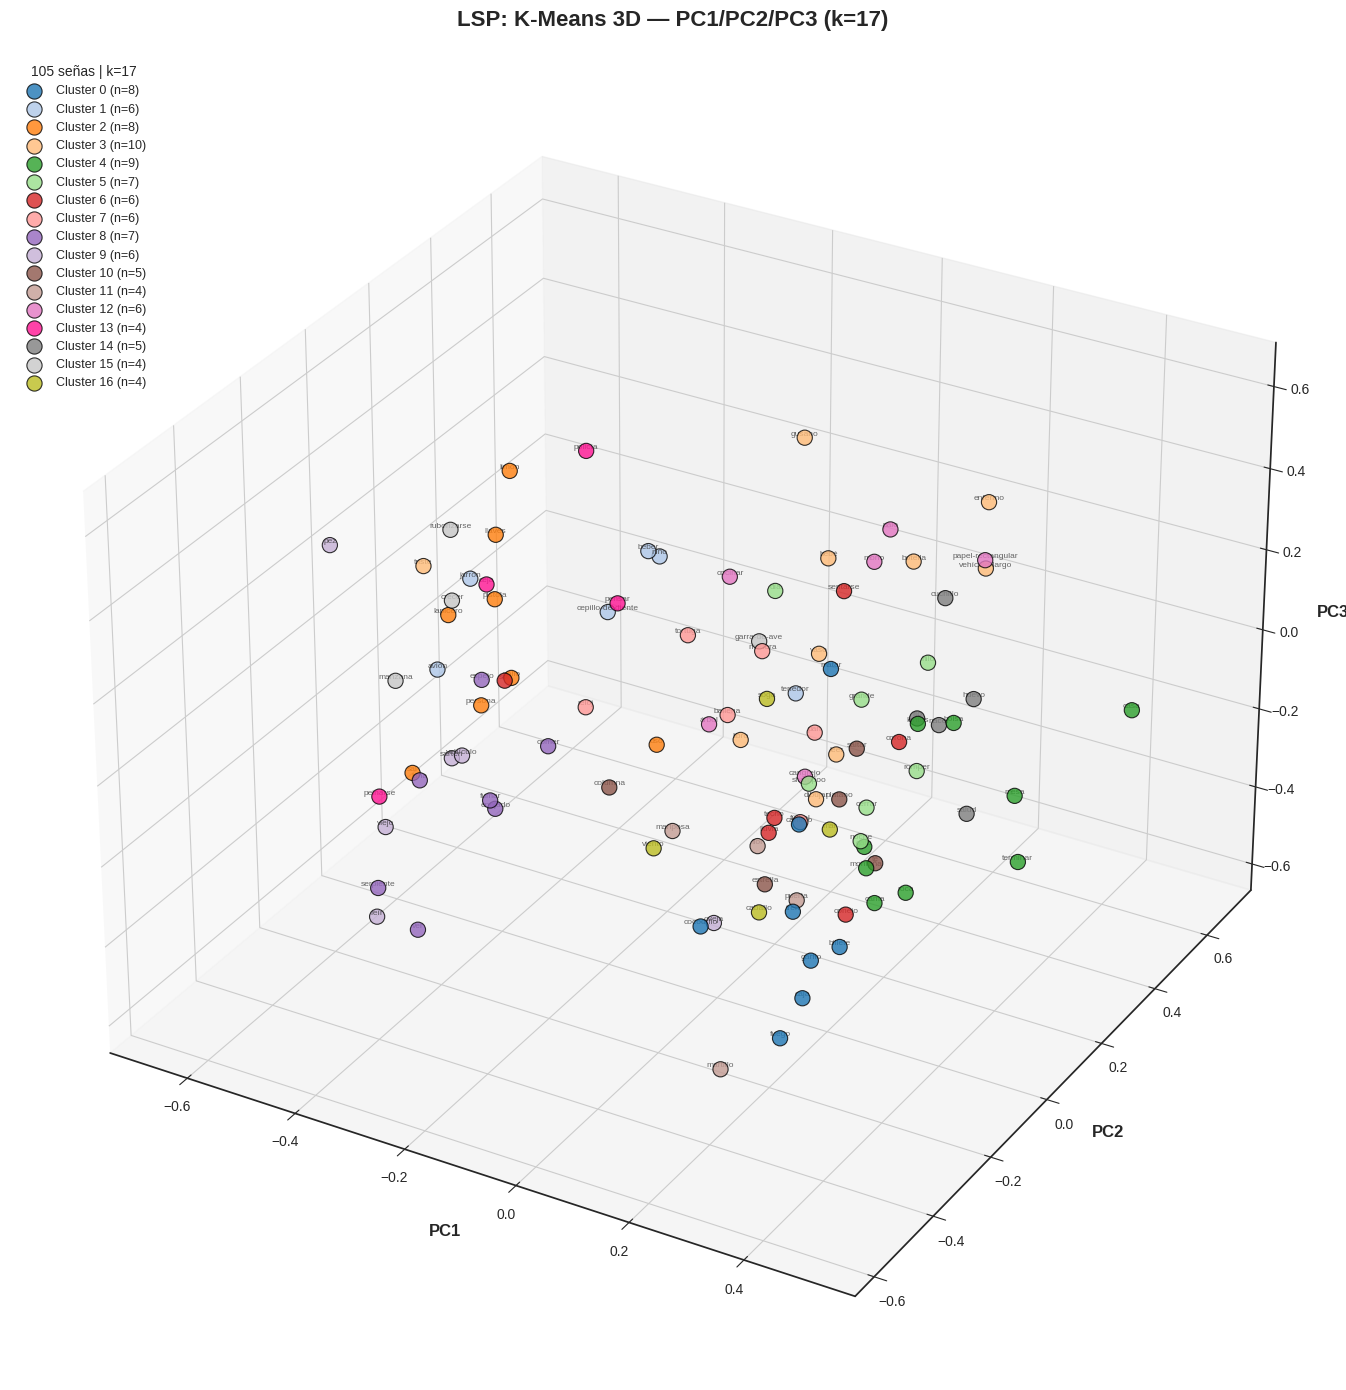

✅ emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_3d_PCA_TSNE.png guardada (105 señas en 3D)


In [37]:
# ==============================================================================
# VISUALIZACIÓN 5: CLUSTERS IN 3D WITH PCA
# ==============================================================================
print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 5: CLUSTERS IN 3D")

plot_kmeans_clusters_3d(sign_data, signLanguage, k_opt,
    f"{fileName}/{fileName}_3d_{reduct_method['methodReduction']}.png")


🎨 VISUALIZACIÓN 5: CLUSTERS IN 3D AND TSNE FOR PLOT
   ✅ T-SNE completado

📊 Generando gráfica 3D para LSP...


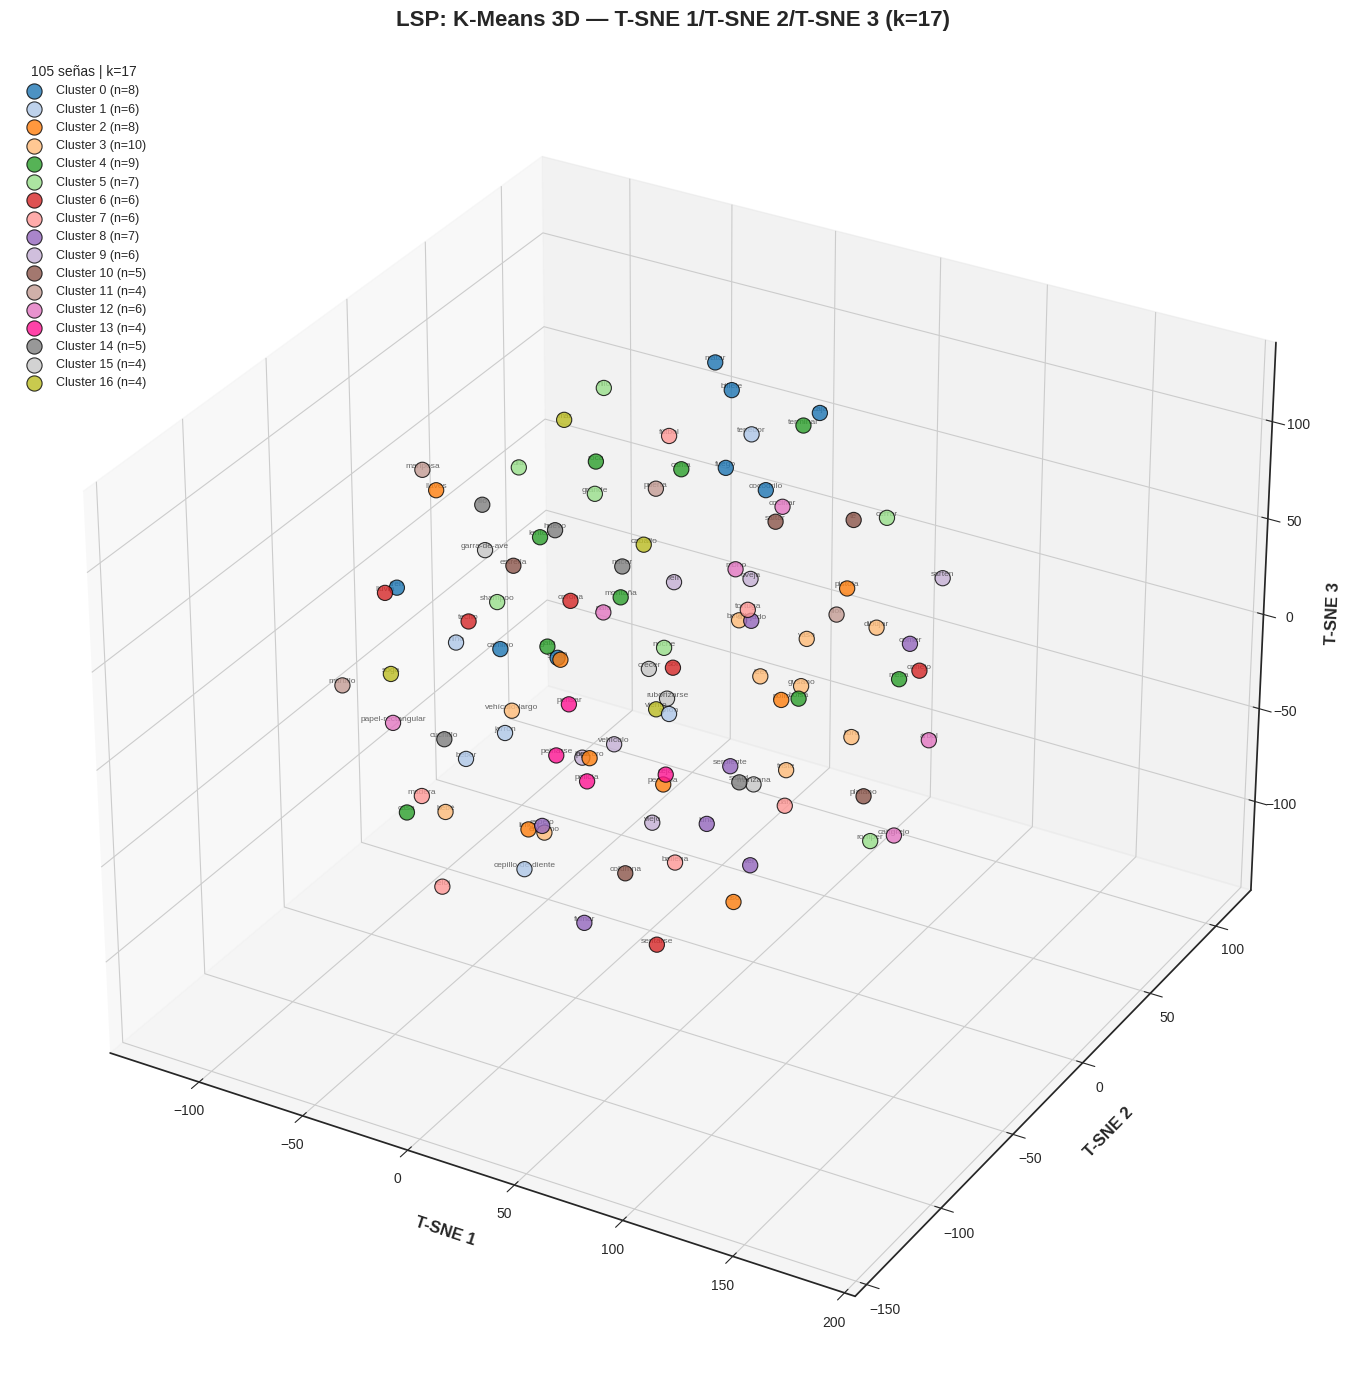

✅ emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_tsne3d.png guardada (105 señas en 3D)


In [38]:
# ==============================================================================
# VISUALIZACIÓN 5: CLUSTERS IN 3D WITH PCA AND TSNE FOR PLOT
# ==============================================================================
print("\n" + "="*80)
print("🎨 VISUALIZACIÓN 5: CLUSTERS IN 3D AND TSNE FOR PLOT")

coords_tsne3d = apply_tsne_3d(coords, signLanguage)
sign_data['tsne_x'] = coords_tsne3d[:, 0]
sign_data['tsne_y'] = coords_tsne3d[:, 1]
sign_data['tsne_z'] = coords_tsne3d[:, 2]

# Plot 3D con T-SNE
plot_kmeans_clusters_3d(sign_data, signLanguage, k_opt,
    f"{fileName}/{fileName}_tsne3d.png",
    x_col='tsne_x', y_col='tsne_y', z_col='tsne_z',
    xlabel='T-SNE 1', ylabel='T-SNE 2', zlabel='T-SNE 3')

### **4. Export results**

In [39]:
sign_data

,word,EnglishGloss,iconicity,0,1,2,3,4,5,6,...,255,icon_category,x,y,z,cluster,tsne_x,tsne_y,dist_to_centroid,tsne_z
0,AVIÓN,PLANE,4.627451,0.055275,-0.108810,0.014533,0.041355,-0.088619,-0.130564,-0.018783,...,-0.000550,8,-0.401716,-0.189474,0.118532,1,49.974350,-56.947319,0.7777,22.657104
1,BALLENA,WHALE,3.823529,0.030203,0.083716,-0.024807,-0.152549,-0.051707,0.058088,0.078909,...,-0.074694,6,-0.113874,0.248177,-0.159864,7,73.509514,-86.317528,0.6463,-25.363136
2,BEBER,DRINK,4.745098,0.051722,0.116147,0.021334,0.065851,-0.121639,-0.048938,-0.027213,...,-0.002671,8,-0.278978,0.284078,0.165471,1,1.410899,-119.026749,0.7820,26.559299
3,BEBÉ,BABY,4.254902,-0.048735,-0.042702,0.118751,0.081172,0.093464,-0.018908,-0.079542,...,0.038967,7,0.140516,0.102646,0.416833,3,-72.773483,-35.960331,0.8356,-83.092155
4,BILLETE,BILL,3.960784,-0.038487,0.037250,-0.044018,-0.005553,-0.058923,0.000919,-0.073150,...,-0.022936,6,0.224020,-0.006771,-0.437408,0,-18.124130,81.838524,0.7677,79.653046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,VEHÍCULO-LARGO,LARGE-VEHICLE,3.882353,-0.013286,0.010156,-0.035889,0.067585,-0.018608,-0.013413,0.000421,...,0.039432,6,0.399376,0.130859,0.473304,3,-88.696358,29.215422,0.9638,-78.504707
101,VER,SEE,4.549020,0.047603,-0.009952,-0.005732,0.034065,-0.013871,0.092315,-0.047374,...,-0.066848,8,-0.221199,-0.572014,-0.195415,8,53.964775,-8.233568,0.6270,-88.923805
102,VIEJO,OLD,4.274510,0.044409,0.045963,0.023768,-0.011563,-0.112801,-0.007945,0.016909,...,0.079148,7,-0.535124,-0.138995,-0.362355,9,-1.916118,4.473552,0.6369,-93.752769
103,VIENTO,WIND,4.529412,0.044835,-0.030418,0.056147,-0.049114,-0.015730,-0.004799,0.037965,...,0.033116,8,0.060217,-0.323883,-0.045634,16,-46.831589,70.146057,0.7785,-92.063721


In [40]:

# ==============================================================================
# Export results
# ==============================================================================

print("\n" + "="*80)
print("Results exported")
print("="*80)

# Guardar DataFrames con resultados
sign_results = sign_data[['word', 'iconicity', 'cluster', #, 'icon_category'
                         'x', 'y', 'z']].copy()
# lsp_results = lsp_data[['word', 'iconicity', 'cluster', #, 'icon_category'
#                          'pc1', 'pc2', 'pc3', 'tsne_x', 'tsne_y']].copy()

sign_results.to_csv(f"{fileName}/{fileName}_kmeans_{reduct_method["methodReduction"]}_results_asl.csv", index=False)
# lsp_results.to_csv(fileName[:-6]+'kmeans_results.csv', index=False)

print("Exported results:")
print("   • kmeans_results_ASL.csv")
print("   • kmeans_results_LSP.csv")


Results exported
Exported results:
   • kmeans_results_ASL.csv
   • kmeans_results_LSP.csv


In [41]:
  !zip -r emb_phono_medoids_LSP_MHIv8.zip emb_phono_medoids_LSP_MHIv8/

  adding: emb_phono_medoids_LSP_MHIv8/ (stored 0%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_3d_PCA_TSNE.png (deflated 11%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_PCA_TSNE_cluster_statistics.txt (deflated 74%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_k17_PCA_TSNE.png (deflated 17%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_gridBy_k17_PCA_TSNE.png (deflated 26%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_elbow_PCA_TSNE.png (deflated 17%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_tsne3d.png (deflated 12%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_iconSize_k17_PCA_TSNE.png (deflated 12%)
  adding: emb_phono_medoids_LSP_MHIv8/emb_phono_medoids_LSP_MHIv8_kmeans_PCA_TSNE_results_asl.csv (deflated 49%)


In [42]:
 from google.colab import files

 files.download("emb_phono_medoids_LSP_MHIv8.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>